<a href="https://colab.research.google.com/github/Akbeherab/CyberRaksha-IDS/blob/main/Classical_ML_Modals1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Machine Learning Model Training

In this stage, the preprocessed CICIDS2017 network-flow data is used to train Machine Learning models for intrusion detection.

We trained and evaluated three different classification models:

1. **Random Forest**
2. **XGBoost**
3. **K-Nearest Neighbors (KNN)**

The models learn patterns from network-flow features such as packet statistics, flow characteristics, ports, services, payload information, TCP flags, and timing-related features.

The objective of the training is to enable the models to identify and classify different types of malicious network traffic.

After training, each model is evaluated on unseen test data using metrics such as:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- Macro F1

We also measure training and inference time to evaluate the suitability of the models for the **EdgeGuard edge-based Intrusion Detection System**.

The trained models and their predictions are subsequently used for comparative performance analysis and attack-level evaluation.

EDGEGUARD - RANDOM FOREST PIPELINE
Dataset : /content/friday.csv
Target  : Attack_type
Output  : /content/edgeguard_RF

1. LOADING DATA
Original shape: (123117, 85)

2. DATA CLEANING
Removed: Unnamed: 0
Rows removed due to missing target: 0
Shape after cleaning: (123117, 84)

3. TARGET DISTRIBUTION
Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64

Number of classes: 12
Classes: ['ARP_poisioning', 'DDOS_Slowloris', 'DOS_SYN_Hping', 'MQTT_Publish', 'Metasploit_Brute_Force_SSH', 'NMAP_FIN_SCAN', 'NMAP_OS_DETECTION', 'NMAP_TCP_scan', 'NMAP_UDP_SCAN', 'NMAP_XMAS_TREE_SCAN', 'Th

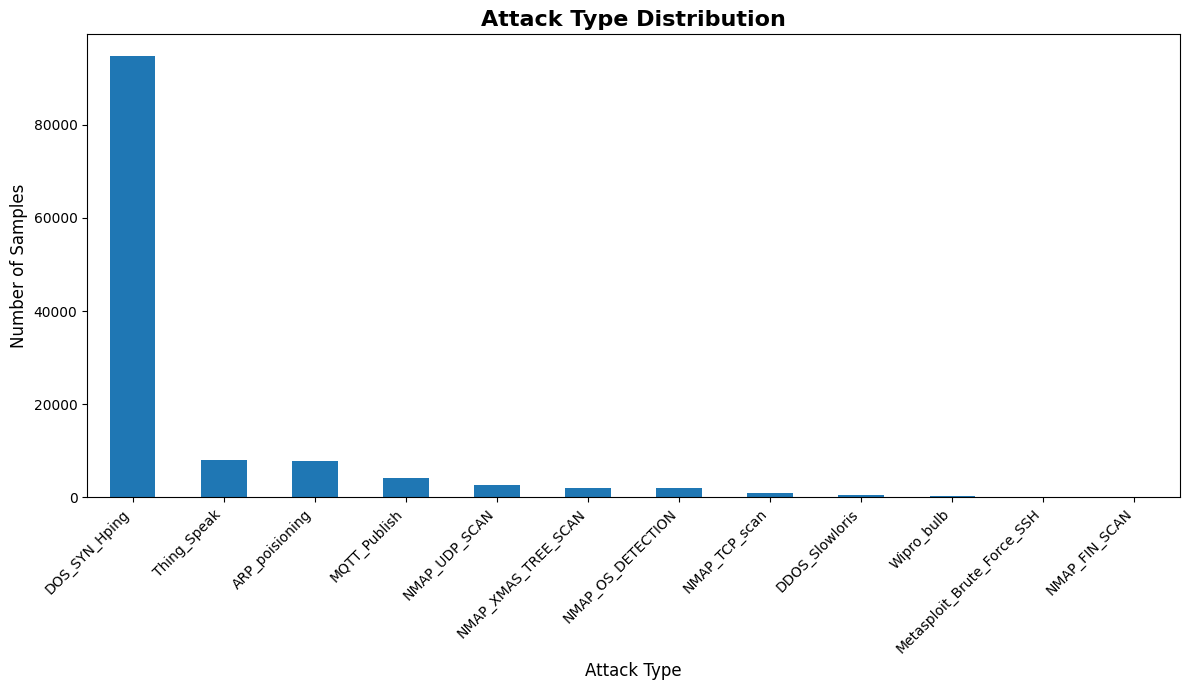

✓ Saved: /content/edgeguard_RF/attack_type_distribution.png

4. FEATURES / TARGET
Number of features: 83
Number of samples: 123117

5. DATA SPLIT
Total      : 123117
Train      : 86181
Validation : 18468
Test       : 18468

6. FEATURE TYPES
Numerical features: 81
Categorical features: 2
Categorical: ['proto', 'service']

7. PREPROCESSING

Fitting preprocessing...
Processed train: (86181, 83)
Processed validation: (18468, 83)
Processed test: (18468, 83)

8. RANDOM FOREST TRAINING
Training time: 8.4189 seconds

9. TEST PREDICTION
Test inference time: 0.4070 seconds
Average inference/sample: 0.022041 ms

10. RANDOM FOREST RESULTS
Accuracy           : 0.9982
Balanced Accuracy  : 0.9757
Precision Weighted : 0.9982
Recall Weighted    : 0.9982
F1 Weighted        : 0.9982
F1 Macro           : 0.9711

11. CLASSIFICATION REPORT
                            precision    recall  f1-score   support

            ARP_poisioning       0.99      0.99      0.99      1162
            DDOS_Slowloris       

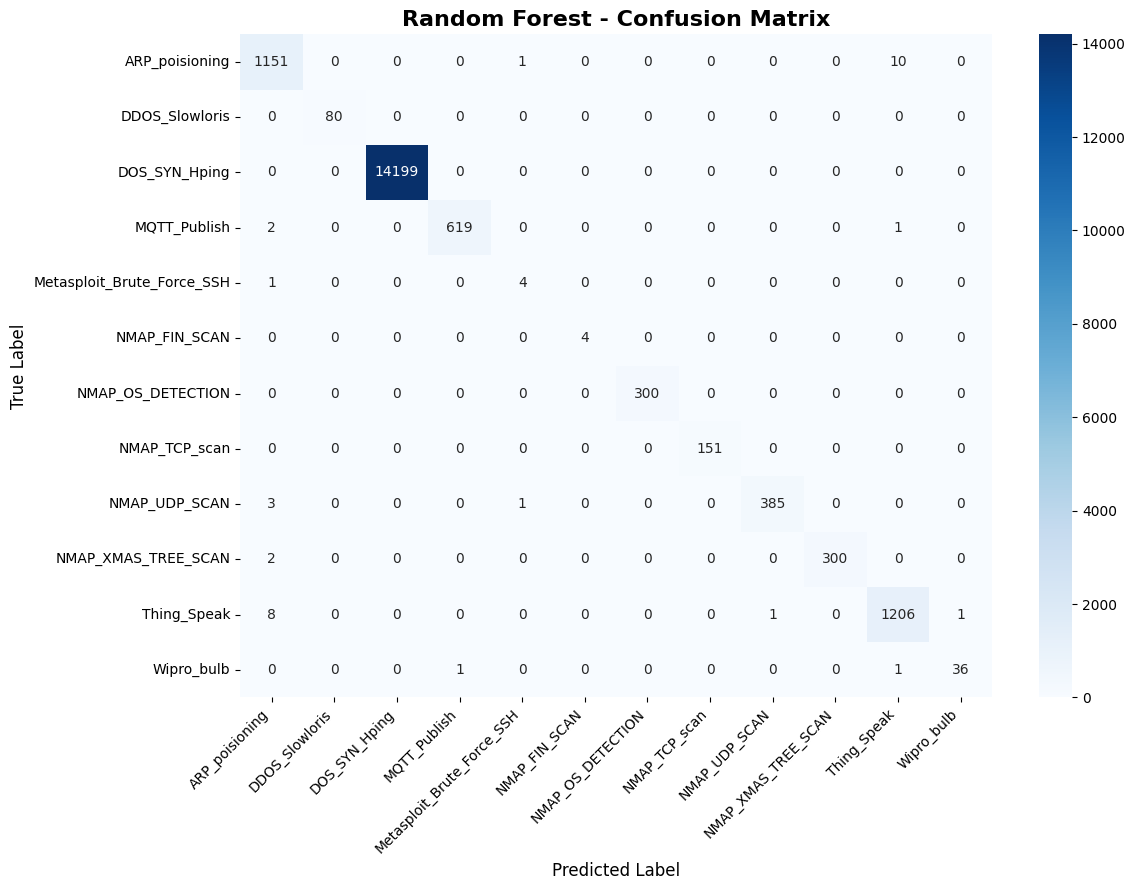

✓ Confusion matrix saved: /content/edgeguard_RF/random_forest_confusion_matrix.png

Generating normalized confusion matrix...


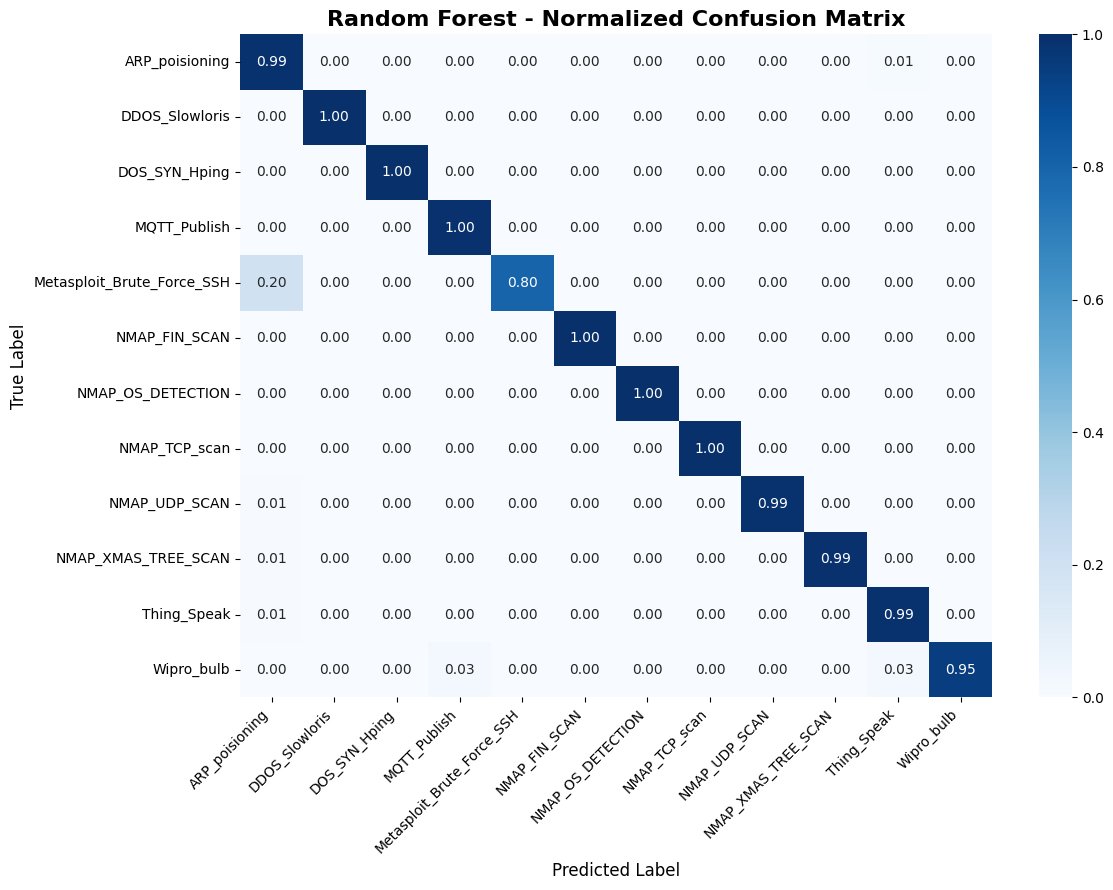

✓ Normalized confusion matrix saved: /content/edgeguard_RF/random_forest_normalized_confusion_matrix.png

13. FEATURE IMPORTANCE

Top 20 Random Forest Features:


,Feature,Importance
0,numeric__fwd_pkts_payload.avg,0.100407
1,numeric__id.resp_p,0.068996
2,numeric__fwd_subflow_bytes,0.068793
3,numeric__fwd_pkts_payload.min,0.063171
4,categorical__service,0.055849
5,numeric__fwd_pkts_payload.tot,0.051813
6,numeric__fwd_pkts_payload.max,0.040188
7,numeric__flow_iat.min,0.026432
8,numeric__fwd_iat.min,0.025828
9,numeric__flow_pkts_payload.max,0.024404


✓ Feature importance CSV saved: /content/edgeguard_RF/rf_feature_importance.csv


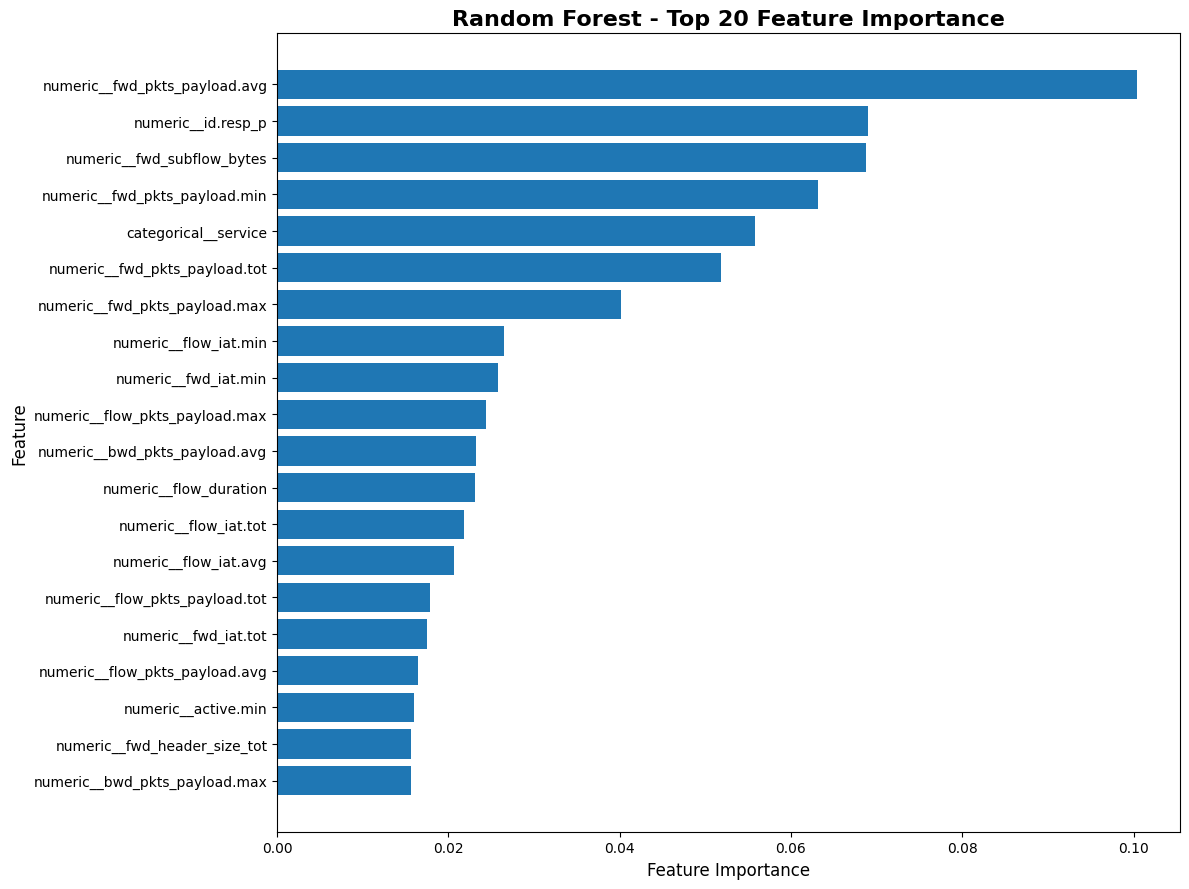

✓ Feature importance graph saved: /content/edgeguard_RF/random_forest_feature_importance.png

Generating performance graph...


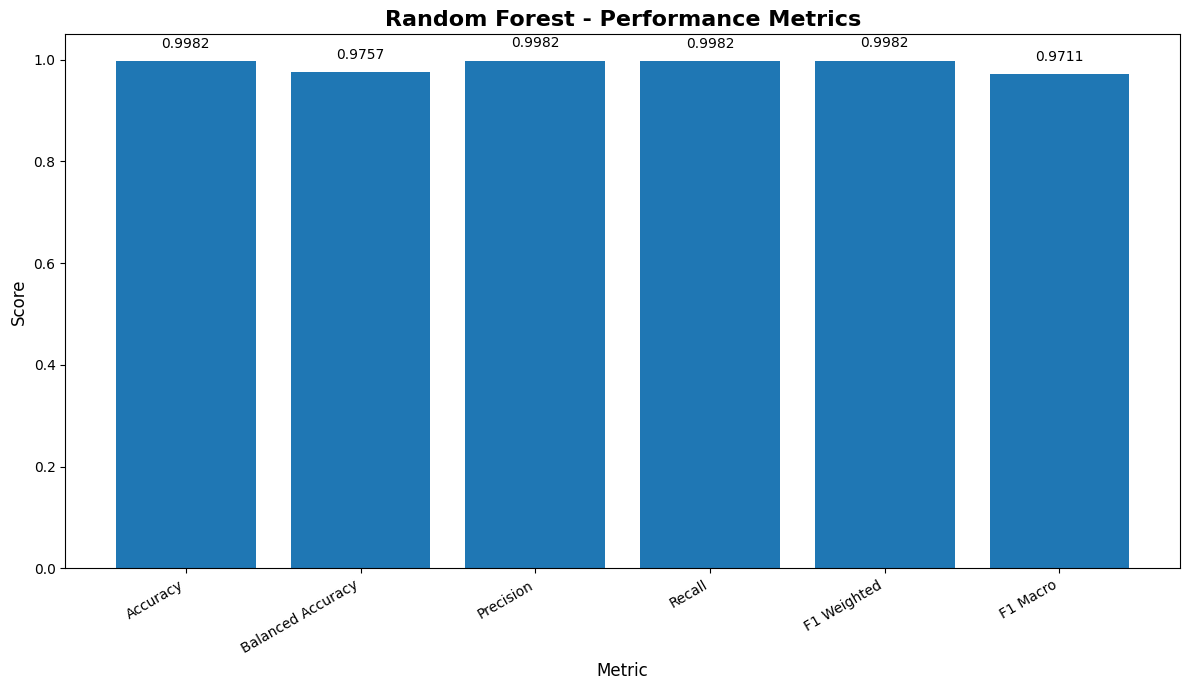

✓ Performance graph saved: /content/edgeguard_RF/random_forest_performance_metrics.png

14. SAVING RESULTS
✓ Metrics saved: /content/edgeguard_RF/random_forest_metrics.csv

Saving test predictions...
✓ Predictions saved: /content/edgeguard_RF/random_forest_predictions.csv

Saving trained model...
✓ Model saved: /content/edgeguard_RF/random_forest_bundle.joblib
✓ Summary saved: /content/edgeguard_RF/random_forest_summary.txt

PIPELINE COMPLETED SUCCESSFULLY

Generated files:
✓ attack_type_distribution.png                      269.02 KB
✓ random_forest_bundle.joblib                       6541.52 KB
✓ random_forest_classification_report.csv           0.92 KB
✓ random_forest_confusion_matrix.png                429.43 KB
✓ random_forest_feature_importance.png              306.27 KB
✓ random_forest_metrics.csv                         0.33 KB
✓ random_forest_normalized_confusion_matrix.png     463.25 KB
✓ random_forest_performance_metrics.png             162.24 KB
✓ random_forest_predictions.

In [8]:
# ================================================================
# EDGEGUARD - RANDOM FOREST COMPLETE PIPELINE
# Dataset: Friday.csv
# Target: Attack_type
# Split: 70% Train / 15% Validation / 15% Test
#
# OUTPUT:
# - Confusion Matrix PNG
# - Feature Importance PNG
# - Attack Distribution PNG
# - Classification Report CSV
# - Metrics CSV
# - Feature Importance CSV
# - Trained Model Bundle
# ================================================================


# ================================================================
# 0. IMPORT LIBRARIES
# ================================================================

import os
import time
import joblib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OrdinalEncoder,
    MinMaxScaler
)

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


warnings.filterwarnings("ignore")


# ================================================================
# 1. CONFIGURATION
# ================================================================

RANDOM_STATE = 42

# Dataset location in Google Colab
CSV_PATH = "/content/friday.csv"

# Target column
TARGET = "Attack_type"

# Main output directory
RF_OUTPUT = "/content/edgeguard_RF"

# Create output directory
os.makedirs(
    RF_OUTPUT,
    exist_ok=True
)

print("=" * 70)
print("EDGEGUARD - RANDOM FOREST PIPELINE")
print("=" * 70)

print("Dataset :", CSV_PATH)
print("Target  :", TARGET)
print("Output  :", RF_OUTPUT)


# ================================================================
# 2. LOAD DATA
# ================================================================

print("\n" + "=" * 70)
print("1. LOADING DATA")
print("=" * 70)

df_rf = pd.read_csv(
    CSV_PATH,
    low_memory=False
)

print("Original shape:", df_rf.shape)


# ================================================================
# 3. BASIC CLEANING
# ================================================================

print("\n" + "=" * 70)
print("2. DATA CLEANING")
print("=" * 70)

# Remove CSV index column if present
if "Unnamed: 0" in df_rf.columns:

    df_rf = df_rf.drop(
        columns=["Unnamed: 0"]
    )

    print("Removed: Unnamed: 0")


# Check target exists
if TARGET not in df_rf.columns:

    raise ValueError(
        f"Target column '{TARGET}' not found in dataset."
    )


# Remove rows with missing target
before_drop = len(df_rf)

df_rf = df_rf.dropna(
    subset=[TARGET]
).copy()

after_drop = len(df_rf)

print(
    "Rows removed due to missing target:",
    before_drop - after_drop
)

print(
    "Shape after cleaning:",
    df_rf.shape
)


# ================================================================
# 4. TARGET DISTRIBUTION
# ================================================================

print("\n" + "=" * 70)
print("3. TARGET DISTRIBUTION")
print("=" * 70)

target_distribution_rf = (
    df_rf[TARGET]
    .value_counts()
)

print(target_distribution_rf)


# Get class names
CLASS_NAMES_RF = sorted(
    df_rf[TARGET].unique()
)

print(
    "\nNumber of classes:",
    len(CLASS_NAMES_RF)
)

print(
    "Classes:",
    CLASS_NAMES_RF
)


# ================================================================
# 5. TARGET DISTRIBUTION GRAPH
# ================================================================

print("\nGenerating attack distribution graph...")

plt.figure(
    figsize=(12, 7)
)

target_distribution_rf.plot(
    kind="bar"
)

plt.title(
    "Attack Type Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Attack Type",
    fontsize=12
)

plt.ylabel(
    "Number of Samples",
    fontsize=12
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

# Save PNG
distribution_path = os.path.join(
    RF_OUTPUT,
    "attack_type_distribution.png"
)

plt.savefig(
    distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    "✓ Saved:",
    distribution_path
)


# ================================================================
# 6. FEATURES / TARGET
# ================================================================

print("\n" + "=" * 70)
print("4. FEATURES / TARGET")
print("=" * 70)

X_rf = df_rf.drop(
    columns=[TARGET]
)

y_rf = df_rf[TARGET]

print(
    "Number of features:",
    X_rf.shape[1]
)

print(
    "Number of samples:",
    X_rf.shape[0]
)


# ================================================================
# 7. TRAIN / VALIDATION / TEST SPLIT
# ================================================================

print("\n" + "=" * 70)
print("5. DATA SPLIT")
print("=" * 70)

# 70% training
# 30% temporary
X_train_rf, X_temp_rf, y_train_rf, y_temp_rf = train_test_split(

    X_rf,
    y_rf,

    test_size=0.30,

    stratify=y_rf,

    random_state=RANDOM_STATE
)


# Split remaining 30% into:
# 15% validation
# 15% test

X_val_rf, X_test_rf, y_val_rf, y_test_rf = train_test_split(

    X_temp_rf,
    y_temp_rf,

    test_size=0.50,

    stratify=y_temp_rf,

    random_state=RANDOM_STATE
)


print(
    "Total      :",
    len(X_rf)
)

print(
    "Train      :",
    len(X_train_rf)
)

print(
    "Validation :",
    len(X_val_rf)
)

print(
    "Test       :",
    len(X_test_rf)
)


# ================================================================
# 8. FEATURE TYPES
# ================================================================

print("\n" + "=" * 70)
print("6. FEATURE TYPES")
print("=" * 70)


# Numerical columns
numeric_features_rf = [

    col

    for col in X_train_rf.columns

    if pd.api.types.is_numeric_dtype(
        X_train_rf[col]
    )
]


# Categorical columns
categorical_features_rf = [

    col

    for col in X_train_rf.columns

    if col not in numeric_features_rf
]


print(
    "Numerical features:",
    len(numeric_features_rf)
)

print(
    "Categorical features:",
    len(categorical_features_rf)
)

if len(categorical_features_rf) > 0:

    print(
        "Categorical:",
        categorical_features_rf
    )


# ================================================================
# 9. PREPROCESSING
# ================================================================

print("\n" + "=" * 70)
print("7. PREPROCESSING")
print("=" * 70)


# Numerical preprocessing
numeric_pipeline_rf = Pipeline([

    (
        "imputer",

        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",

        MinMaxScaler()
    )

])


# Categorical preprocessing
categorical_pipeline_rf = Pipeline([

    (
        "imputer",

        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "encoder",

        OrdinalEncoder(

            handle_unknown="use_encoded_value",

            unknown_value=-1

        )
    )

])


# Combined preprocessor
preprocessor_rf = ColumnTransformer([

    (
        "numeric",

        numeric_pipeline_rf,

        numeric_features_rf
    ),

    (
        "categorical",

        categorical_pipeline_rf,

        categorical_features_rf
    )

])


print(
    "\nFitting preprocessing..."
)


# Fit only on training data
X_train_rf_processed = (
    preprocessor_rf.fit_transform(
        X_train_rf
    )
)


# Transform validation
X_val_rf_processed = (
    preprocessor_rf.transform(
        X_val_rf
    )
)


# Transform test
X_test_rf_processed = (
    preprocessor_rf.transform(
        X_test_rf
    )
)


print(
    "Processed train:",
    X_train_rf_processed.shape
)

print(
    "Processed validation:",
    X_val_rf_processed.shape
)

print(
    "Processed test:",
    X_test_rf_processed.shape
)


# ================================================================
# 10. RANDOM FOREST MODEL
# ================================================================

print("\n" + "=" * 70)
print("8. RANDOM FOREST TRAINING")
print("=" * 70)


rf_model = RandomForestClassifier(

    n_estimators=100,

    max_depth=12,

    min_samples_split=2,

    random_state=RANDOM_STATE,

    n_jobs=-1

)


# Start training timer
start_train_rf = time.time()


# Train
rf_model.fit(

    X_train_rf_processed,

    y_train_rf

)


# Training time
rf_training_time = (
    time.time() - start_train_rf
)


print(
    f"Training time: "
    f"{rf_training_time:.4f} seconds"
)


# ================================================================
# 11. TEST PREDICTION
# ================================================================

print("\n" + "=" * 70)
print("9. TEST PREDICTION")
print("=" * 70)


start_test_rf = time.time()


# Predictions
rf_predictions = rf_model.predict(
    X_test_rf_processed
)


# Probabilities
rf_probabilities = rf_model.predict_proba(
    X_test_rf_processed
)


# Inference time
rf_inference_time = (
    time.time() - start_test_rf
)


print(
    f"Test inference time: "
    f"{rf_inference_time:.4f} seconds"
)


# Average inference time
avg_inference_ms = (
    rf_inference_time
    / len(X_test_rf)
    * 1000
)


print(
    f"Average inference/sample: "
    f"{avg_inference_ms:.6f} ms"
)


# ================================================================
# 12. EVALUATION
# ================================================================

print("\n" + "=" * 70)
print("10. RANDOM FOREST RESULTS")
print("=" * 70)


# Accuracy
rf_accuracy = accuracy_score(

    y_test_rf,

    rf_predictions

)


# Balanced accuracy
rf_balanced_accuracy = (
    balanced_accuracy_score(

        y_test_rf,

        rf_predictions

    )
)


# Weighted precision
rf_precision = precision_score(

    y_test_rf,

    rf_predictions,

    average="weighted",

    zero_division=0

)


# Weighted recall
rf_recall = recall_score(

    y_test_rf,

    rf_predictions,

    average="weighted",

    zero_division=0

)


# Weighted F1
rf_f1_weighted = f1_score(

    y_test_rf,

    rf_predictions,

    average="weighted",

    zero_division=0

)


# Macro F1
rf_f1_macro = f1_score(

    y_test_rf,

    rf_predictions,

    average="macro",

    zero_division=0

)


print(
    f"Accuracy           : "
    f"{rf_accuracy:.4f}"
)

print(
    f"Balanced Accuracy  : "
    f"{rf_balanced_accuracy:.4f}"
)

print(
    f"Precision Weighted : "
    f"{rf_precision:.4f}"
)

print(
    f"Recall Weighted    : "
    f"{rf_recall:.4f}"
)

print(
    f"F1 Weighted        : "
    f"{rf_f1_weighted:.4f}"
)

print(
    f"F1 Macro           : "
    f"{rf_f1_macro:.4f}"
)


# ================================================================
# 13. CLASSIFICATION REPORT
# ================================================================

print("\n" + "=" * 70)
print("11. CLASSIFICATION REPORT")
print("=" * 70)


# Print report
print(

    classification_report(

        y_test_rf,

        rf_predictions,

        zero_division=0

    )

)


# Create dictionary report
rf_report = classification_report(

    y_test_rf,

    rf_predictions,

    output_dict=True,

    zero_division=0

)


# Convert to DataFrame
rf_report_df = pd.DataFrame(
    rf_report
).transpose()


# Save report
report_path = os.path.join(

    RF_OUTPUT,

    "random_forest_classification_report.csv"

)


rf_report_df.to_csv(

    report_path

)


print(
    "✓ Classification report saved:",
    report_path
)


# ================================================================
# 14. CONFUSION MATRIX
# ================================================================

print("\n" + "=" * 70)
print("12. CONFUSION MATRIX")
print("=" * 70)


rf_cm = confusion_matrix(

    y_test_rf,

    rf_predictions,

    labels=CLASS_NAMES_RF

)


print("\nConfusion Matrix:")

print(rf_cm)


# Create figure
plt.figure(

    figsize=(12, 9)

)


# Heatmap
sns.heatmap(

    rf_cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=CLASS_NAMES_RF,

    yticklabels=CLASS_NAMES_RF,

    cbar=True

)


plt.title(

    "Random Forest - Confusion Matrix",

    fontsize=16,

    fontweight="bold"

)


plt.xlabel(

    "Predicted Label",

    fontsize=12

)


plt.ylabel(

    "True Label",

    fontsize=12

)


plt.xticks(

    rotation=45,

    ha="right"

)


plt.yticks(

    rotation=0

)


plt.tight_layout()


# Save PNG
cm_path = os.path.join(

    RF_OUTPUT,

    "random_forest_confusion_matrix.png"

)


plt.savefig(

    cm_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Confusion matrix saved:",
    cm_path
)


# ================================================================
# 15. NORMALIZED CONFUSION MATRIX
# ================================================================

print("\nGenerating normalized confusion matrix...")


# Normalize each row
rf_cm_normalized = (

    rf_cm.astype(float)

    / rf_cm.sum(
        axis=1,
        keepdims=True
    )

)


# Avoid NaN
rf_cm_normalized = np.nan_to_num(
    rf_cm_normalized
)


plt.figure(

    figsize=(12, 9)

)


sns.heatmap(

    rf_cm_normalized,

    annot=True,

    fmt=".2f",

    cmap="Blues",

    xticklabels=CLASS_NAMES_RF,

    yticklabels=CLASS_NAMES_RF,

    vmin=0,

    vmax=1

)


plt.title(

    "Random Forest - Normalized Confusion Matrix",

    fontsize=16,

    fontweight="bold"

)


plt.xlabel(

    "Predicted Label",

    fontsize=12

)


plt.ylabel(

    "True Label",

    fontsize=12

)


plt.xticks(

    rotation=45,

    ha="right"

)


plt.yticks(

    rotation=0

)


plt.tight_layout()


normalized_cm_path = os.path.join(

    RF_OUTPUT,

    "random_forest_normalized_confusion_matrix.png"

)


plt.savefig(

    normalized_cm_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Normalized confusion matrix saved:",
    normalized_cm_path
)


# ================================================================
# 16. FEATURE IMPORTANCE
# ================================================================

print("\n" + "=" * 70)
print("13. FEATURE IMPORTANCE")
print("=" * 70)


# Get transformed feature names
feature_names_rf = (

    preprocessor_rf

    .get_feature_names_out()

)


# Create DataFrame
rf_importance = pd.DataFrame({

    "Feature":
        feature_names_rf,

    "Importance":
        rf_model.feature_importances_

})


# Sort
rf_importance = (

    rf_importance

    .sort_values(

        "Importance",

        ascending=False

    )

    .reset_index(

        drop=True

    )

)


# Display top 20
print("\nTop 20 Random Forest Features:")

display(

    rf_importance.head(20)

)


# Save complete feature importance
importance_csv_path = os.path.join(

    RF_OUTPUT,

    "rf_feature_importance.csv"

)


rf_importance.to_csv(

    importance_csv_path,

    index=False

)


print(
    "✓ Feature importance CSV saved:",
    importance_csv_path
)


# ================================================================
# 17. TOP 20 FEATURE IMPORTANCE GRAPH
# ================================================================

top20_rf = (

    rf_importance

    .head(20)

)


plt.figure(

    figsize=(12, 9)

)


plt.barh(

    top20_rf["Feature"][::-1],

    top20_rf["Importance"][::-1]

)


plt.xlabel(

    "Feature Importance",

    fontsize=12

)


plt.ylabel(

    "Feature",

    fontsize=12

)


plt.title(

    "Random Forest - Top 20 Feature Importance",

    fontsize=16,

    fontweight="bold"

)


plt.tight_layout()


# Save PNG
feature_importance_path = os.path.join(

    RF_OUTPUT,

    "random_forest_feature_importance.png"

)


plt.savefig(

    feature_importance_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Feature importance graph saved:",
    feature_importance_path
)


# ================================================================
# 18. MODEL PERFORMANCE GRAPH
# ================================================================

print("\nGenerating performance graph...")


performance_metrics = {

    "Accuracy":
        rf_accuracy,

    "Balanced Accuracy":
        rf_balanced_accuracy,

    "Precision":
        rf_precision,

    "Recall":
        rf_recall,

    "F1 Weighted":
        rf_f1_weighted,

    "F1 Macro":
        rf_f1_macro

}


plt.figure(

    figsize=(12, 7)

)


bars = plt.bar(

    performance_metrics.keys(),

    performance_metrics.values()

)


plt.ylim(

    0,

    1.05

)


plt.ylabel(

    "Score",

    fontsize=12

)


plt.xlabel(

    "Metric",

    fontsize=12

)


plt.title(

    "Random Forest - Performance Metrics",

    fontsize=16,

    fontweight="bold"

)


plt.xticks(

    rotation=30,

    ha="right"

)


# Add values above bars
for bar, value in zip(

    bars,

    performance_metrics.values()

):

    plt.text(

        bar.get_x()
        + bar.get_width() / 2,

        value + 0.02,

        f"{value:.4f}",

        ha="center",

        va="bottom",

        fontsize=10

    )


plt.tight_layout()


performance_graph_path = os.path.join(

    RF_OUTPUT,

    "random_forest_performance_metrics.png"

)


plt.savefig(

    performance_graph_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Performance graph saved:",
    performance_graph_path
)


# ================================================================
# 19. SAVE METRICS
# ================================================================

print("\n" + "=" * 70)
print("14. SAVING RESULTS")
print("=" * 70)


rf_results = pd.DataFrame([{

    "Model":
        "Random Forest",

    "Accuracy":
        rf_accuracy,

    "Balanced_Accuracy":
        rf_balanced_accuracy,

    "Precision_Weighted":
        rf_precision,

    "Recall_Weighted":
        rf_recall,

    "F1_Weighted":
        rf_f1_weighted,

    "F1_Macro":
        rf_f1_macro,

    "Training_Time_sec":
        rf_training_time,

    "Inference_Time_sec":
        rf_inference_time,

    "Inference_Per_Sample_ms":
        avg_inference_ms

}])


# Save metrics
metrics_path = os.path.join(

    RF_OUTPUT,

    "random_forest_metrics.csv"

)


rf_results.to_csv(

    metrics_path,

    index=False

)


print(
    "✓ Metrics saved:",
    metrics_path
)


# ================================================================
# 20. SAVE PREDICTIONS
# ================================================================

print("\nSaving test predictions...")


prediction_df = pd.DataFrame({

    "Actual_Label":
        y_test_rf.values,

    "Predicted_Label":
        rf_predictions,

})


# Add confidence
prediction_df["Confidence"] = (
    rf_probabilities.max(axis=1)
)


prediction_path = os.path.join(

    RF_OUTPUT,

    "random_forest_predictions.csv"

)


prediction_df.to_csv(

    prediction_path,

    index=False

)


print(
    "✓ Predictions saved:",
    prediction_path
)


# ================================================================
# 21. SAVE MODEL BUNDLE
# ================================================================

print("\nSaving trained model...")


model_path = os.path.join(

    RF_OUTPUT,

    "random_forest_bundle.joblib"

)


joblib.dump(

    {

        "model":
            rf_model,

        "preprocessor":
            preprocessor_rf,

        "features":
            X_rf.columns.tolist(),

        "classes":
            CLASS_NAMES_RF

    },

    model_path

)


print(
    "✓ Model saved:",
    model_path
)


# ================================================================
# 22. SAVE A TEXT SUMMARY
# ================================================================

summary_path = os.path.join(

    RF_OUTPUT,

    "random_forest_summary.txt"

)


with open(

    summary_path,

    "w"

) as f:

    f.write(
        "EDGEGUARD - RANDOM FOREST RESULTS\n"
    )

    f.write(
        "=" * 60 + "\n\n"
    )

    f.write(
        f"Dataset: {CSV_PATH}\n"
    )

    f.write(
        f"Target: {TARGET}\n\n"
    )

    f.write(
        "DATA SPLIT\n"
    )

    f.write(
        f"Total: {len(X_rf)}\n"
    )

    f.write(
        f"Train: {len(X_train_rf)}\n"
    )

    f.write(
        f"Validation: {len(X_val_rf)}\n"
    )

    f.write(
        f"Test: {len(X_test_rf)}\n\n"
    )

    f.write(
        "MODEL PERFORMANCE\n"
    )

    f.write(
        f"Accuracy: {rf_accuracy:.4f}\n"
    )

    f.write(
        f"Balanced Accuracy: "
        f"{rf_balanced_accuracy:.4f}\n"
    )

    f.write(
        f"Precision Weighted: "
        f"{rf_precision:.4f}\n"
    )

    f.write(
        f"Recall Weighted: "
        f"{rf_recall:.4f}\n"
    )

    f.write(
        f"F1 Weighted: "
        f"{rf_f1_weighted:.4f}\n"
    )

    f.write(
        f"F1 Macro: "
        f"{rf_f1_macro:.4f}\n"
    )

    f.write(
        f"Training Time: "
        f"{rf_training_time:.4f} sec\n"
    )

    f.write(
        f"Inference Time: "
        f"{rf_inference_time:.4f} sec\n"
    )

    f.write(
        f"Average Inference: "
        f"{avg_inference_ms:.6f} ms/sample\n"
    )


print(
    "✓ Summary saved:",
    summary_path
)


# ================================================================
# 23. FINAL OUTPUT LIST
# ================================================================

print("\n" + "=" * 70)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nGenerated files:")

for file_name in sorted(
    os.listdir(RF_OUTPUT)
):

    file_path = os.path.join(
        RF_OUTPUT,
        file_name
    )

    if os.path.isfile(file_path):

        size_kb = (
            os.path.getsize(file_path)
            / 1024
        )

        print(
            f"✓ {file_name:<50}"
            f"{size_kb:.2f} KB"
        )


print("\nOutput directory:")

print(RF_OUTPUT)

print("\n✓ Random Forest pipeline completed.")

EDGEGUARD - XGBOOST PIPELINE
Dataset : /content/friday.csv
Target  : Attack_type
Output  : /content/edgeguard_XGBoost

1. LOADING DATA
Original shape: (123117, 85)

2. DATA CLEANING
Removed: Unnamed: 0
Rows removed: 0
Shape after cleaning: (123117, 84)

3. TARGET DISTRIBUTION
Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64

Number of classes: 12
Classes: ['ARP_poisioning', 'DDOS_Slowloris', 'DOS_SYN_Hping', 'MQTT_Publish', 'Metasploit_Brute_Force_SSH', 'NMAP_FIN_SCAN', 'NMAP_OS_DETECTION', 'NMAP_TCP_scan', 'NMAP_UDP_SCAN', 'NMAP_XMAS_TREE_SCAN', 'Thing_Speak', 'Wipro_bulb

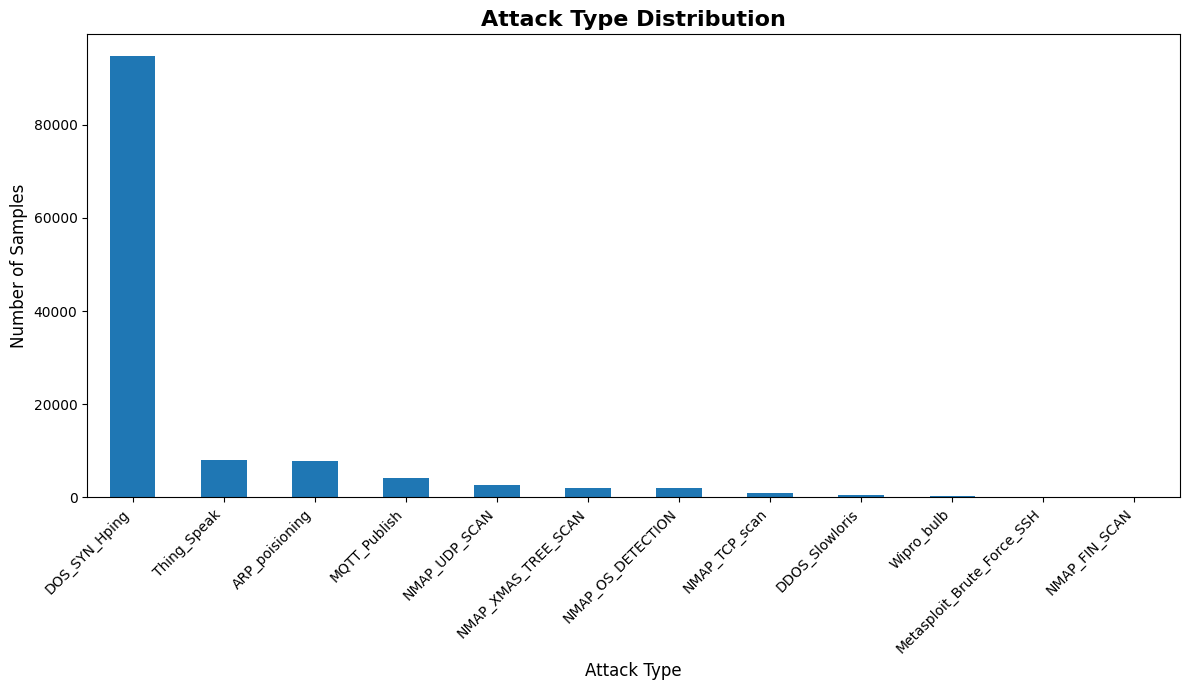

✓ Saved: /content/edgeguard_XGBoost/attack_type_distribution.png

4. FEATURES / TARGET
Number of samples: 123117
Number of features: 83

5. TARGET ENCODING
Target mapping:
0 -> ARP_poisioning
1 -> DDOS_Slowloris
2 -> DOS_SYN_Hping
3 -> MQTT_Publish
4 -> Metasploit_Brute_Force_SSH
5 -> NMAP_FIN_SCAN
6 -> NMAP_OS_DETECTION
7 -> NMAP_TCP_scan
8 -> NMAP_UDP_SCAN
9 -> NMAP_XMAS_TREE_SCAN
10 -> Thing_Speak
11 -> Wipro_bulb

6. DATA SPLIT
Total      : 123117
Train      : 86181
Validation : 18468
Test       : 18468

7. FEATURE TYPES
Numerical features: 81
Categorical features: 2
Categorical: ['proto', 'service']

8. PREPROCESSING
Fitting preprocessing...
Processed train: (86181, 83)
Processed validation: (18468, 83)
Processed test: (18468, 83)

9. XGBOOST TRAINING
Training time: 64.3421 seconds

10. TEST PREDICTION
Test inference time: 1.2323 seconds
Average inference/sample: 0.066726 ms

11. XGBOOST RESULTS
Accuracy           : 0.9984
Balanced Accuracy  : 0.9772
Precision Weighted : 0.9984
Re

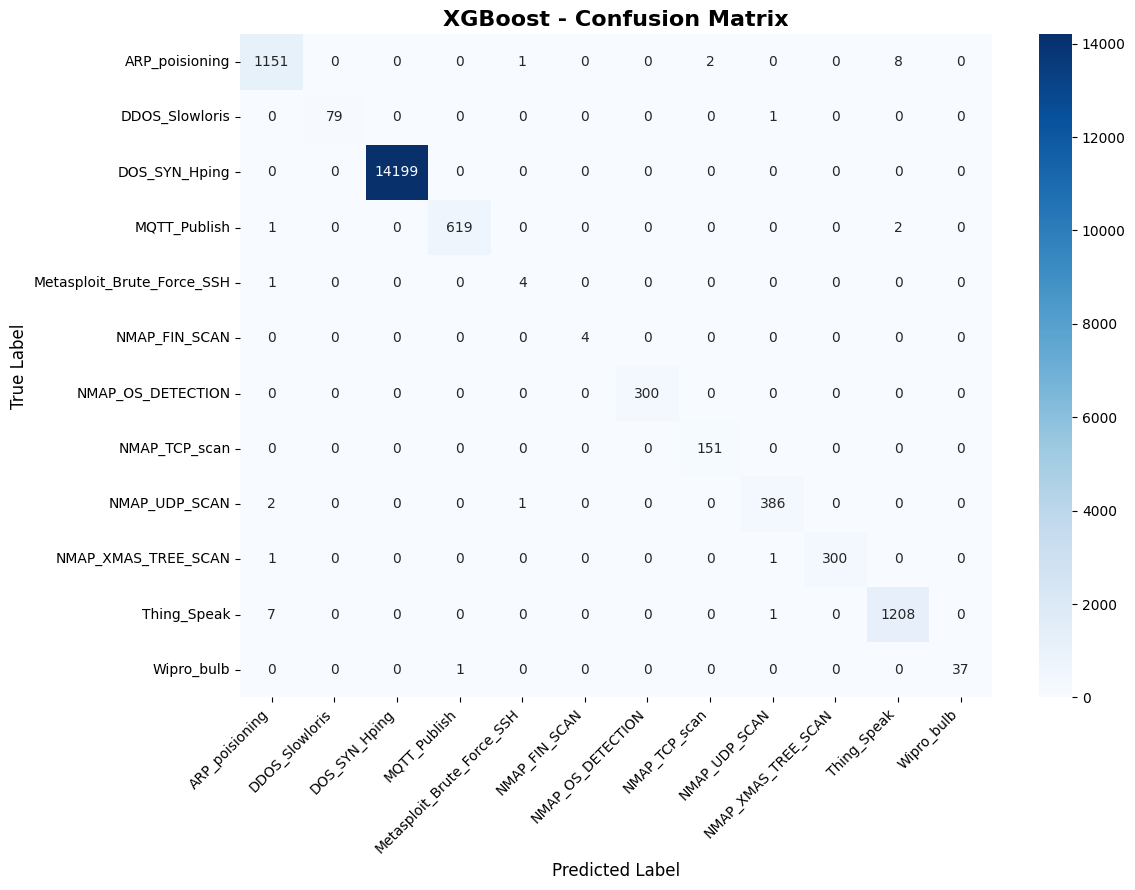

✓ Confusion matrix saved: /content/edgeguard_XGBoost/xgboost_confusion_matrix.png

Generating normalized confusion matrix...


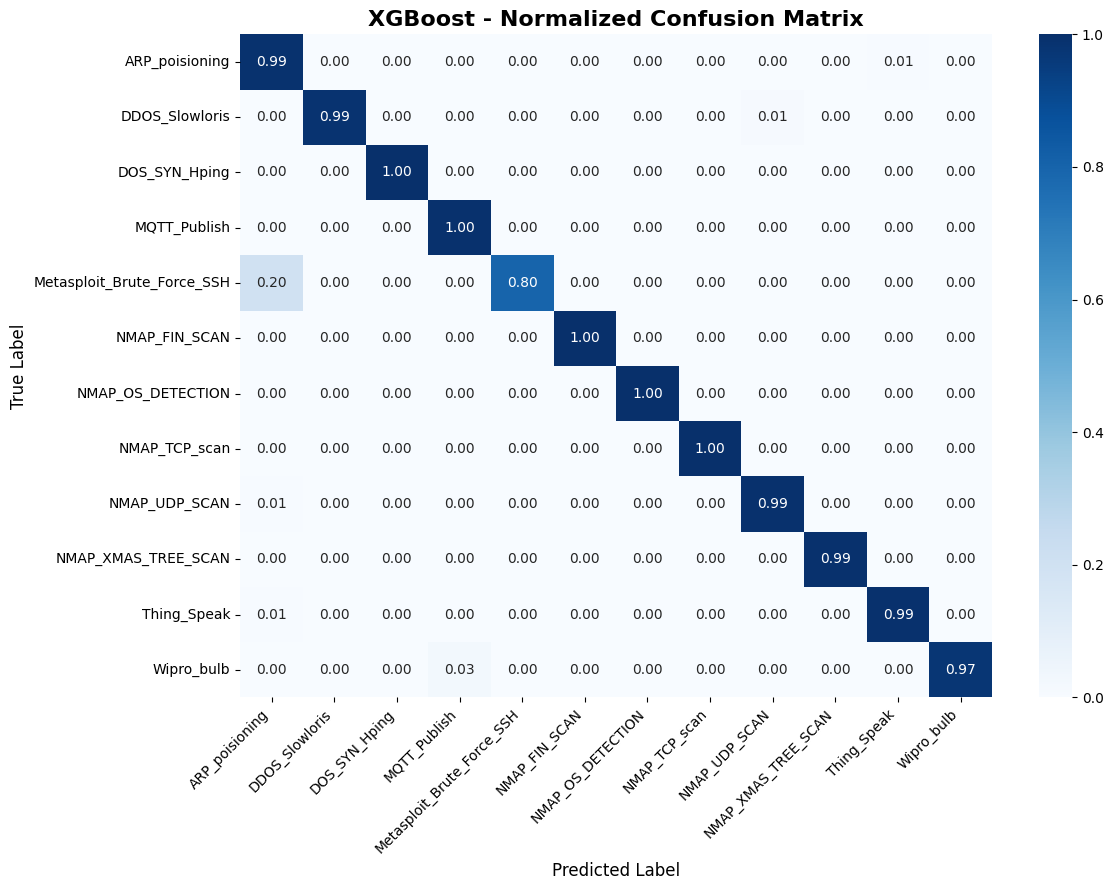

✓ Normalized confusion matrix saved: /content/edgeguard_XGBoost/xgboost_normalized_confusion_matrix.png

14. FEATURE IMPORTANCE

Top 20 XGBoost Features:


,Feature,Importance
0,numeric__bwd_pkts_payload.std,0.190329
1,numeric__fwd_URG_flag_count,0.089001
2,numeric__fwd_PSH_flag_count,0.063838
3,numeric__id.resp_p,0.056150
4,numeric__fwd_last_window_size,0.055620
5,categorical__service,0.050082
6,numeric__fwd_init_window_size,0.045274
7,numeric__bwd_pkts_payload.avg,0.040395
8,numeric__active.avg,0.037328
9,numeric__fwd_header_size_min,0.035336


✓ Feature importance CSV saved: /content/edgeguard_XGBoost/xgboost_feature_importance.csv


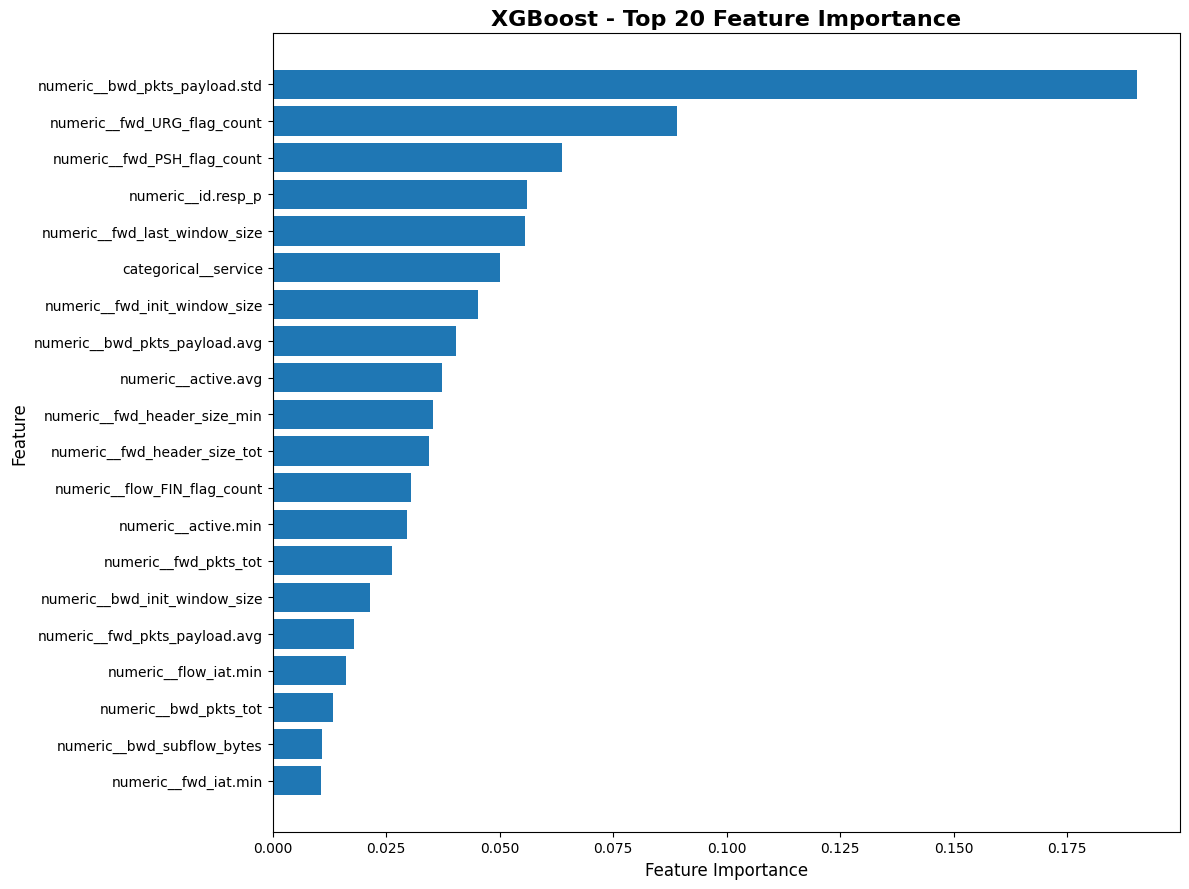

✓ Feature importance graph saved: /content/edgeguard_XGBoost/xgboost_feature_importance.png

Generating performance graph...


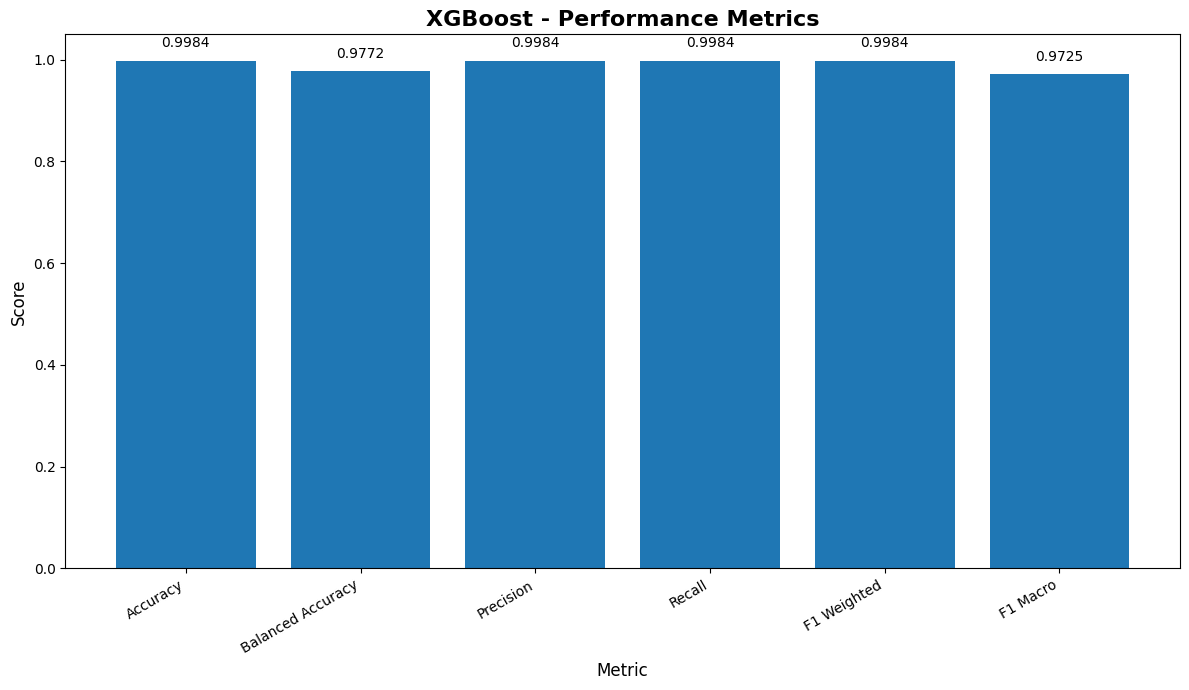

✓ Performance graph saved: /content/edgeguard_XGBoost/xgboost_performance_metrics.png

15. SAVING METRICS
✓ Metrics saved: /content/edgeguard_XGBoost/xgboost_metrics.csv

Saving test predictions...
✓ Predictions saved: /content/edgeguard_XGBoost/xgboost_predictions.csv

Saving trained XGBoost model...
✓ Model saved: /content/edgeguard_XGBoost/xgboost_bundle.joblib
✓ Summary saved: /content/edgeguard_XGBoost/xgboost_summary.txt

XGBOOST PIPELINE COMPLETED SUCCESSFULLY

Generated files:
✓ attack_type_distribution.png                           269.02 KB
✓ xgb_feature_importance.csv                             3.10 KB
✓ xgb_results.csv                                        0.28 KB
✓ xgboost_bundle.joblib                                  3049.32 KB
✓ xgboost_classification_report.csv                      0.97 KB
✓ xgboost_confusion_matrix.png                           427.14 KB
✓ xgboost_feature_importance.csv                         3.10 KB
✓ xgboost_feature_importance.png                

In [9]:
# ================================================================
# EDGEGUARD - XGBOOST COMPLETE PIPELINE
# Dataset: Friday.csv
# Target: Attack_type
# Split: 70% Train / 15% Validation / 15% Test
#
# OUTPUT:
# - Confusion Matrix PNG
# - Normalized Confusion Matrix PNG
# - Feature Importance PNG
# - Attack Distribution PNG
# - Performance Metrics PNG
# - Classification Report CSV
# - Metrics CSV
# - Predictions CSV
# - Feature Importance CSV
# - Trained Model Bundle
# ================================================================


# ================================================================
# 0. INSTALL XGBOOST IF REQUIRED
# ================================================================

# Uncomment if XGBoost is not installed in Colab:
# !pip install -q xgboost


# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import os
import time
import joblib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OrdinalEncoder,
    MinMaxScaler
)

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier


warnings.filterwarnings("ignore")


# ================================================================
# 2. CONFIGURATION
# ================================================================

RANDOM_STATE = 42

CSV_PATH = "/content/friday.csv"

TARGET = "Attack_type"

XGB_OUTPUT = "/content/edgeguard_XGBoost"

os.makedirs(
    XGB_OUTPUT,
    exist_ok=True
)

print("=" * 70)
print("EDGEGUARD - XGBOOST PIPELINE")
print("=" * 70)

print("Dataset :", CSV_PATH)
print("Target  :", TARGET)
print("Output  :", XGB_OUTPUT)


# ================================================================
# 3. LOAD DATA
# ================================================================

print("\n" + "=" * 70)
print("1. LOADING DATA")
print("=" * 70)

df_xgb = pd.read_csv(
    CSV_PATH,
    low_memory=False
)

print(
    "Original shape:",
    df_xgb.shape
)


# ================================================================
# 4. BASIC CLEANING
# ================================================================

print("\n" + "=" * 70)
print("2. DATA CLEANING")
print("=" * 70)

# Remove CSV index column
if "Unnamed: 0" in df_xgb.columns:

    df_xgb = df_xgb.drop(
        columns=["Unnamed: 0"]
    )

    print("Removed: Unnamed: 0")


# Check target
if TARGET not in df_xgb.columns:

    raise ValueError(
        f"Target column '{TARGET}' not found."
    )


# Remove missing target rows
before_drop = len(df_xgb)

df_xgb = df_xgb.dropna(
    subset=[TARGET]
).copy()

after_drop = len(df_xgb)

print(
    "Rows removed:",
    before_drop - after_drop
)

print(
    "Shape after cleaning:",
    df_xgb.shape
)


# ================================================================
# 5. TARGET DISTRIBUTION
# ================================================================

print("\n" + "=" * 70)
print("3. TARGET DISTRIBUTION")
print("=" * 70)

target_distribution_xgb = (
    df_xgb[TARGET]
    .value_counts()
)

print(
    target_distribution_xgb
)


# Class names
CLASS_NAMES_XGB = sorted(
    df_xgb[TARGET].unique()
)

print(
    "\nNumber of classes:",
    len(CLASS_NAMES_XGB)
)

print(
    "Classes:",
    CLASS_NAMES_XGB
)


# ================================================================
# 6. TARGET DISTRIBUTION GRAPH
# ================================================================

print(
    "\nGenerating attack distribution graph..."
)

plt.figure(
    figsize=(12, 7)
)

target_distribution_xgb.plot(
    kind="bar"
)

plt.title(
    "Attack Type Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Attack Type",
    fontsize=12
)

plt.ylabel(
    "Number of Samples",
    fontsize=12
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()


distribution_path = os.path.join(
    XGB_OUTPUT,
    "attack_type_distribution.png"
)

plt.savefig(
    distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    "✓ Saved:",
    distribution_path
)


# ================================================================
# 7. FEATURES / TARGET
# ================================================================

print("\n" + "=" * 70)
print("4. FEATURES / TARGET")
print("=" * 70)

X_xgb = df_xgb.drop(
    columns=[TARGET]
)

y_xgb = df_xgb[TARGET]


print(
    "Number of samples:",
    X_xgb.shape[0]
)

print(
    "Number of features:",
    X_xgb.shape[1]
)


# ================================================================
# 8. ENCODE TARGET
# ================================================================

print("\n" + "=" * 70)
print("5. TARGET ENCODING")
print("=" * 70)

# XGBoost multiclass classification requires
# integer class labels.

target_encoder_xgb = OrdinalEncoder()

y_xgb_encoded = (
    target_encoder_xgb.fit_transform(
        y_xgb.to_frame()
    )
    .ravel()
    .astype(int)
)

# Mapping
target_mapping_xgb = {

    int(i):
        str(class_name)

    for i, class_name
    in enumerate(
        target_encoder_xgb.categories_[0]
    )

}

print(
    "Target mapping:"
)

for key, value in target_mapping_xgb.items():

    print(
        f"{key} -> {value}"
    )


# ================================================================
# 9. TRAIN / VALIDATION / TEST SPLIT
# ================================================================

print("\n" + "=" * 70)
print("6. DATA SPLIT")
print("=" * 70)


# 70% train
# 30% temporary

X_train_xgb, X_temp_xgb, y_train_xgb, y_temp_xgb = train_test_split(

    X_xgb,

    y_xgb_encoded,

    test_size=0.30,

    stratify=y_xgb_encoded,

    random_state=RANDOM_STATE

)


# Remaining 30%
# 15% validation
# 15% test

X_val_xgb, X_test_xgb, y_val_xgb, y_test_xgb = train_test_split(

    X_temp_xgb,

    y_temp_xgb,

    test_size=0.50,

    stratify=y_temp_xgb,

    random_state=RANDOM_STATE

)


print(
    "Total      :",
    len(X_xgb)
)

print(
    "Train      :",
    len(X_train_xgb)
)

print(
    "Validation :",
    len(X_val_xgb)
)

print(
    "Test       :",
    len(X_test_xgb)
)


# ================================================================
# 10. FEATURE TYPES
# ================================================================

print("\n" + "=" * 70)
print("7. FEATURE TYPES")
print("=" * 70)


numeric_features_xgb = [

    col

    for col in X_train_xgb.columns

    if pd.api.types.is_numeric_dtype(
        X_train_xgb[col]
    )

]


categorical_features_xgb = [

    col

    for col in X_train_xgb.columns

    if col not in numeric_features_xgb

]


print(
    "Numerical features:",
    len(numeric_features_xgb)
)

print(
    "Categorical features:",
    len(categorical_features_xgb)
)


if len(categorical_features_xgb) > 0:

    print(
        "Categorical:",
        categorical_features_xgb
    )


# ================================================================
# 11. PREPROCESSING
# ================================================================

print("\n" + "=" * 70)
print("8. PREPROCESSING")
print("=" * 70)


# Numerical pipeline
numeric_pipeline_xgb = Pipeline([

    (
        "imputer",

        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",

        MinMaxScaler()
    )

])


# Categorical pipeline
categorical_pipeline_xgb = Pipeline([

    (
        "imputer",

        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "encoder",

        OrdinalEncoder(

            handle_unknown="use_encoded_value",

            unknown_value=-1

        )
    )

])


# Combined preprocessor
preprocessor_xgb = ColumnTransformer([

    (
        "numeric",

        numeric_pipeline_xgb,

        numeric_features_xgb
    ),

    (
        "categorical",

        categorical_pipeline_xgb,

        categorical_features_xgb
    )

])


print(
    "Fitting preprocessing..."
)


# Training
X_train_xgb_processed = (
    preprocessor_xgb.fit_transform(
        X_train_xgb
    )
)


# Validation
X_val_xgb_processed = (
    preprocessor_xgb.transform(
        X_val_xgb
    )
)


# Test
X_test_xgb_processed = (
    preprocessor_xgb.transform(
        X_test_xgb
    )
)


print(
    "Processed train:",
    X_train_xgb_processed.shape
)

print(
    "Processed validation:",
    X_val_xgb_processed.shape
)

print(
    "Processed test:",
    X_test_xgb_processed.shape
)


# ================================================================
# 12. XGBOOST MODEL
# ================================================================

print("\n" + "=" * 70)
print("9. XGBOOST TRAINING")
print("=" * 70)


num_classes_xgb = len(
    CLASS_NAMES_XGB
)


xgb_model = XGBClassifier(

    n_estimators=200,

    max_depth=8,

    learning_rate=0.1,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="multi:softprob",

    num_class=num_classes_xgb,

    eval_metric="mlogloss",

    random_state=RANDOM_STATE,

    n_jobs=-1,

    tree_method="hist"

)


# Start training timer
start_train_xgb = time.time()


# Train model
xgb_model.fit(

    X_train_xgb_processed,

    y_train_xgb

)


# Training time
xgb_training_time = (
    time.time() - start_train_xgb
)


print(
    f"Training time: "
    f"{xgb_training_time:.4f} seconds"
)


# ================================================================
# 13. TEST PREDICTION
# ================================================================

print("\n" + "=" * 70)
print("10. TEST PREDICTION")
print("=" * 70)


start_test_xgb = time.time()


# Prediction
xgb_predictions = xgb_model.predict(
    X_test_xgb_processed
)


# Probabilities
xgb_probabilities = (
    xgb_model.predict_proba(
        X_test_xgb_processed
    )
)


# Inference time
xgb_inference_time = (
    time.time() - start_test_xgb
)


avg_inference_ms = (

    xgb_inference_time
    / len(X_test_xgb)
    * 1000

)


print(
    f"Test inference time: "
    f"{xgb_inference_time:.4f} seconds"
)

print(
    f"Average inference/sample: "
    f"{avg_inference_ms:.6f} ms"
)


# ================================================================
# 14. DECODE PREDICTIONS
# ================================================================

xgb_actual_labels = [

    target_mapping_xgb[
        int(label)
    ]

    for label in y_test_xgb

]


xgb_predicted_labels = [

    target_mapping_xgb[
        int(label)
    ]

    for label in xgb_predictions

]


# ================================================================
# 15. EVALUATION
# ================================================================

print("\n" + "=" * 70)
print("11. XGBOOST RESULTS")
print("=" * 70)


xgb_accuracy = accuracy_score(

    y_test_xgb,

    xgb_predictions

)


xgb_balanced_accuracy = (
    balanced_accuracy_score(

        y_test_xgb,

        xgb_predictions

    )
)


xgb_precision = precision_score(

    y_test_xgb,

    xgb_predictions,

    average="weighted",

    zero_division=0

)


xgb_recall = recall_score(

    y_test_xgb,

    xgb_predictions,

    average="weighted",

    zero_division=0

)


xgb_f1_weighted = f1_score(

    y_test_xgb,

    xgb_predictions,

    average="weighted",

    zero_division=0

)


xgb_f1_macro = f1_score(

    y_test_xgb,

    xgb_predictions,

    average="macro",

    zero_division=0

)


print(
    f"Accuracy           : "
    f"{xgb_accuracy:.4f}"
)

print(
    f"Balanced Accuracy  : "
    f"{xgb_balanced_accuracy:.4f}"
)

print(
    f"Precision Weighted : "
    f"{xgb_precision:.4f}"
)

print(
    f"Recall Weighted    : "
    f"{xgb_recall:.4f}"
)

print(
    f"F1 Weighted        : "
    f"{xgb_f1_weighted:.4f}"
)

print(
    f"F1 Macro           : "
    f"{xgb_f1_macro:.4f}"
)


# ================================================================
# 16. CLASSIFICATION REPORT
# ================================================================

print("\n" + "=" * 70)
print("12. CLASSIFICATION REPORT")
print("=" * 70)


print(

    classification_report(

        y_test_xgb,

        xgb_predictions,

        target_names=CLASS_NAMES_XGB,

        zero_division=0

    )

)


# Generate report dictionary
xgb_report = classification_report(

    y_test_xgb,

    xgb_predictions,

    target_names=CLASS_NAMES_XGB,

    output_dict=True,

    zero_division=0

)


xgb_report_df = pd.DataFrame(
    xgb_report
).transpose()


# Save classification report
report_path = os.path.join(

    XGB_OUTPUT,

    "xgboost_classification_report.csv"

)


xgb_report_df.to_csv(

    report_path

)


print(
    "✓ Classification report saved:",
    report_path
)


# ================================================================
# 17. CONFUSION MATRIX
# ================================================================

print("\n" + "=" * 70)
print("13. CONFUSION MATRIX")
print("=" * 70)


xgb_cm = confusion_matrix(

    y_test_xgb,

    xgb_predictions,

    labels=list(
        range(num_classes_xgb)
    )

)


print(
    "\nConfusion Matrix:"
)

print(
    xgb_cm
)


plt.figure(

    figsize=(12, 9)

)


sns.heatmap(

    xgb_cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=CLASS_NAMES_XGB,

    yticklabels=CLASS_NAMES_XGB,

    cbar=True

)


plt.title(

    "XGBoost - Confusion Matrix",

    fontsize=16,

    fontweight="bold"

)


plt.xlabel(

    "Predicted Label",

    fontsize=12

)


plt.ylabel(

    "True Label",

    fontsize=12

)


plt.xticks(

    rotation=45,

    ha="right"

)


plt.yticks(

    rotation=0

)


plt.tight_layout()


cm_path = os.path.join(

    XGB_OUTPUT,

    "xgboost_confusion_matrix.png"

)


plt.savefig(

    cm_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Confusion matrix saved:",
    cm_path
)


# ================================================================
# 18. NORMALIZED CONFUSION MATRIX
# ================================================================

print(
    "\nGenerating normalized confusion matrix..."
)


xgb_cm_normalized = (

    xgb_cm.astype(float)

    / xgb_cm.sum(
        axis=1,
        keepdims=True
    )

)


# Avoid NaN
xgb_cm_normalized = np.nan_to_num(
    xgb_cm_normalized
)


plt.figure(

    figsize=(12, 9)

)


sns.heatmap(

    xgb_cm_normalized,

    annot=True,

    fmt=".2f",

    cmap="Blues",

    xticklabels=CLASS_NAMES_XGB,

    yticklabels=CLASS_NAMES_XGB,

    vmin=0,

    vmax=1

)


plt.title(

    "XGBoost - Normalized Confusion Matrix",

    fontsize=16,

    fontweight="bold"

)


plt.xlabel(

    "Predicted Label",

    fontsize=12

)


plt.ylabel(

    "True Label",

    fontsize=12

)


plt.xticks(

    rotation=45,

    ha="right"

)


plt.yticks(

    rotation=0

)


plt.tight_layout()


normalized_cm_path = os.path.join(

    XGB_OUTPUT,

    "xgboost_normalized_confusion_matrix.png"

)


plt.savefig(

    normalized_cm_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Normalized confusion matrix saved:",
    normalized_cm_path
)


# ================================================================
# 19. FEATURE IMPORTANCE
# ================================================================

print("\n" + "=" * 70)
print("14. FEATURE IMPORTANCE")
print("=" * 70)


feature_names_xgb = (

    preprocessor_xgb

    .get_feature_names_out()

)


xgb_importance = pd.DataFrame({

    "Feature":
        feature_names_xgb,

    "Importance":
        xgb_model.feature_importances_

})


xgb_importance = (

    xgb_importance

    .sort_values(

        "Importance",

        ascending=False

    )

    .reset_index(

        drop=True

    )

)


print(
    "\nTop 20 XGBoost Features:"
)


display(

    xgb_importance.head(20)

)


# Save CSV
importance_csv_path = os.path.join(

    XGB_OUTPUT,

    "xgboost_feature_importance.csv"

)


xgb_importance.to_csv(

    importance_csv_path,

    index=False

)


print(
    "✓ Feature importance CSV saved:",
    importance_csv_path
)


# ================================================================
# 20. FEATURE IMPORTANCE GRAPH
# ================================================================

top20_xgb = (

    xgb_importance

    .head(20)

)


plt.figure(

    figsize=(12, 9)

)


plt.barh(

    top20_xgb["Feature"][::-1],

    top20_xgb["Importance"][::-1]

)


plt.xlabel(

    "Feature Importance",

    fontsize=12

)


plt.ylabel(

    "Feature",

    fontsize=12

)


plt.title(

    "XGBoost - Top 20 Feature Importance",

    fontsize=16,

    fontweight="bold"

)


plt.tight_layout()


feature_importance_path = os.path.join(

    XGB_OUTPUT,

    "xgboost_feature_importance.png"

)


plt.savefig(

    feature_importance_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Feature importance graph saved:",
    feature_importance_path
)


# ================================================================
# 21. MODEL PERFORMANCE GRAPH
# ================================================================

print(
    "\nGenerating performance graph..."
)


performance_metrics = {

    "Accuracy":
        xgb_accuracy,

    "Balanced Accuracy":
        xgb_balanced_accuracy,

    "Precision":
        xgb_precision,

    "Recall":
        xgb_recall,

    "F1 Weighted":
        xgb_f1_weighted,

    "F1 Macro":
        xgb_f1_macro

}


plt.figure(

    figsize=(12, 7)

)


bars = plt.bar(

    performance_metrics.keys(),

    performance_metrics.values()

)


plt.ylim(

    0,

    1.05

)


plt.ylabel(

    "Score",

    fontsize=12

)


plt.xlabel(

    "Metric",

    fontsize=12

)


plt.title(

    "XGBoost - Performance Metrics",

    fontsize=16,

    fontweight="bold"

)


plt.xticks(

    rotation=30,

    ha="right"

)


# Add values
for bar, value in zip(

    bars,

    performance_metrics.values()

):

    plt.text(

        bar.get_x()
        + bar.get_width() / 2,

        value + 0.02,

        f"{value:.4f}",

        ha="center",

        va="bottom",

        fontsize=10

    )


plt.tight_layout()


performance_graph_path = os.path.join(

    XGB_OUTPUT,

    "xgboost_performance_metrics.png"

)


plt.savefig(

    performance_graph_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Performance graph saved:",
    performance_graph_path
)


# ================================================================
# 22. SAVE METRICS
# ================================================================

print("\n" + "=" * 70)
print("15. SAVING METRICS")
print("=" * 70)


xgb_results = pd.DataFrame([{

    "Model":
        "XGBoost",

    "Accuracy":
        xgb_accuracy,

    "Balanced_Accuracy":
        xgb_balanced_accuracy,

    "Precision_Weighted":
        xgb_precision,

    "Recall_Weighted":
        xgb_recall,

    "F1_Weighted":
        xgb_f1_weighted,

    "F1_Macro":
        xgb_f1_macro,

    "Training_Time_sec":
        xgb_training_time,

    "Inference_Time_sec":
        xgb_inference_time,

    "Inference_Per_Sample_ms":
        avg_inference_ms

}])


metrics_path = os.path.join(

    XGB_OUTPUT,

    "xgboost_metrics.csv"

)


xgb_results.to_csv(

    metrics_path,

    index=False

)


print(
    "✓ Metrics saved:",
    metrics_path
)


# ================================================================
# 23. SAVE TEST PREDICTIONS
# ================================================================

print(
    "\nSaving test predictions..."
)


prediction_df = pd.DataFrame({

    "Actual_Label":
        xgb_actual_labels,

    "Predicted_Label":
        xgb_predicted_labels,

    "Confidence":
        xgb_probabilities.max(
            axis=1
        )

})


prediction_path = os.path.join(

    XGB_OUTPUT,

    "xgboost_predictions.csv"

)


prediction_df.to_csv(

    prediction_path,

    index=False

)


print(
    "✓ Predictions saved:",
    prediction_path
)


# ================================================================
# 24. SAVE MODEL BUNDLE
# ================================================================

print(
    "\nSaving trained XGBoost model..."
)


model_path = os.path.join(

    XGB_OUTPUT,

    "xgboost_bundle.joblib"

)


joblib.dump(

    {

        "model":
            xgb_model,

        "preprocessor":
            preprocessor_xgb,

        "target_encoder":
            target_encoder_xgb,

        "features":
            X_xgb.columns.tolist(),

        "classes":
            CLASS_NAMES_XGB,

        "target_mapping":
            target_mapping_xgb

    },

    model_path

)


print(
    "✓ Model saved:",
    model_path
)


# ================================================================
# 25. SAVE TEXT SUMMARY
# ================================================================

summary_path = os.path.join(

    XGB_OUTPUT,

    "xgboost_summary.txt"

)


with open(

    summary_path,

    "w"

) as f:

    f.write(
        "EDGEGUARD - XGBOOST RESULTS\n"
    )

    f.write(
        "=" * 60 + "\n\n"
    )

    f.write(
        f"Dataset: {CSV_PATH}\n"
    )

    f.write(
        f"Target: {TARGET}\n\n"
    )

    f.write(
        "DATA SPLIT\n"
    )

    f.write(
        f"Total: {len(X_xgb)}\n"
    )

    f.write(
        f"Train: {len(X_train_xgb)}\n"
    )

    f.write(
        f"Validation: {len(X_val_xgb)}\n"
    )

    f.write(
        f"Test: {len(X_test_xgb)}\n\n"
    )

    f.write(
        "MODEL PERFORMANCE\n"
    )

    f.write(
        f"Accuracy: {xgb_accuracy:.4f}\n"
    )

    f.write(
        f"Balanced Accuracy: "
        f"{xgb_balanced_accuracy:.4f}\n"
    )

    f.write(
        f"Precision Weighted: "
        f"{xgb_precision:.4f}\n"
    )

    f.write(
        f"Recall Weighted: "
        f"{xgb_recall:.4f}\n"
    )

    f.write(
        f"F1 Weighted: "
        f"{xgb_f1_weighted:.4f}\n"
    )

    f.write(
        f"F1 Macro: "
        f"{xgb_f1_macro:.4f}\n"
    )

    f.write(
        f"Training Time: "
        f"{xgb_training_time:.4f} sec\n"
    )

    f.write(
        f"Inference Time: "
        f"{xgb_inference_time:.4f} sec\n"
    )

    f.write(
        f"Average Inference: "
        f"{avg_inference_ms:.6f} ms/sample\n"
    )


print(
    "✓ Summary saved:",
    summary_path
)


# ================================================================
# 26. FINAL OUTPUT LIST
# ================================================================

print("\n" + "=" * 70)
print("XGBOOST PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nGenerated files:")


for file_name in sorted(

    os.listdir(
        XGB_OUTPUT
    )

):

    file_path = os.path.join(

        XGB_OUTPUT,

        file_name

    )

    if os.path.isfile(
        file_path
    ):

        size_kb = (

            os.path.getsize(
                file_path
            )
            / 1024

        )

        print(

            f"✓ {file_name:<55}"
            f"{size_kb:.2f} KB"

        )


print(
    "\nOutput directory:"
)

print(
    XGB_OUTPUT
)

print(
    "\n✓ XGBoost pipeline completed successfully."
)

EDGEGUARD - KNN PIPELINE
Dataset : /content/friday.csv
Target  : Attack_type
Output  : /content/edgeguard_KNN

1. LOADING DATA
Original shape: (123117, 85)

2. DATA CLEANING
Removed: Unnamed: 0
Rows removed due to missing target: 0
Shape after cleaning: (123117, 84)

3. TARGET DISTRIBUTION
Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64

Number of classes: 12
Classes: ['ARP_poisioning', 'DDOS_Slowloris', 'DOS_SYN_Hping', 'MQTT_Publish', 'Metasploit_Brute_Force_SSH', 'NMAP_FIN_SCAN', 'NMAP_OS_DETECTION', 'NMAP_TCP_scan', 'NMAP_UDP_SCAN', 'NMAP_XMAS_TREE_SCAN', 'Thing_Speak

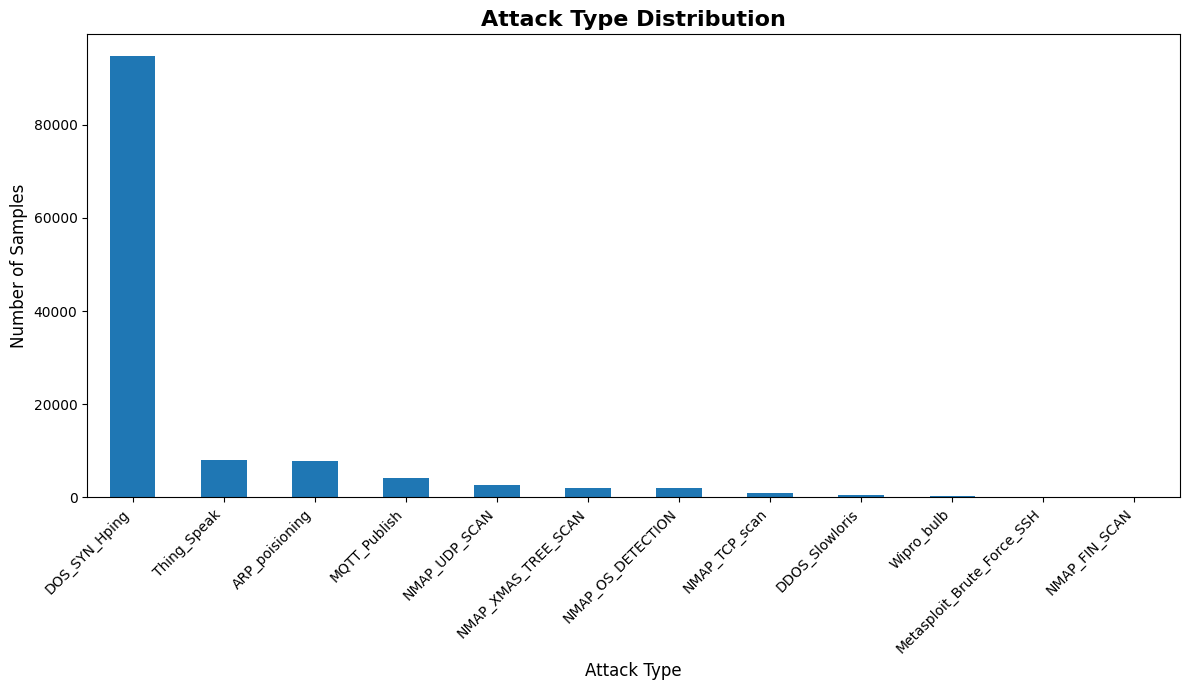

✓ Saved: /content/edgeguard_KNN/attack_type_distribution.png

4. FEATURES / TARGET
Number of samples: 123117
Number of features: 83

5. DATA SPLIT
Total      : 123117
Train      : 86181
Validation : 18468
Test       : 18468

6. FEATURE TYPES
Numerical features: 81
Categorical features: 2
Categorical: ['proto', 'service']

7. PREPROCESSING
Fitting preprocessing...
Processed train: (86181, 83)
Processed validation: (18468, 83)
Processed test: (18468, 83)

8. KNN TRAINING
K: 5
Weights: distance
Metric: Euclidean distance
Training time: 0.1020 seconds

9. VALIDATION
Validation Accuracy: 0.9970

10. TEST PREDICTION
Test inference time: 36.6760 seconds
Average inference/sample: 1.985923 ms

11. KNN RESULTS
Accuracy           : 0.9972
Balanced Accuracy  : 0.9856
Precision Weighted : 0.9973
Recall Weighted    : 0.9972
F1 Weighted        : 0.9972
F1 Macro           : 0.9765

12. CLASSIFICATION REPORT
                            precision    recall  f1-score   support

            ARP_poisioning

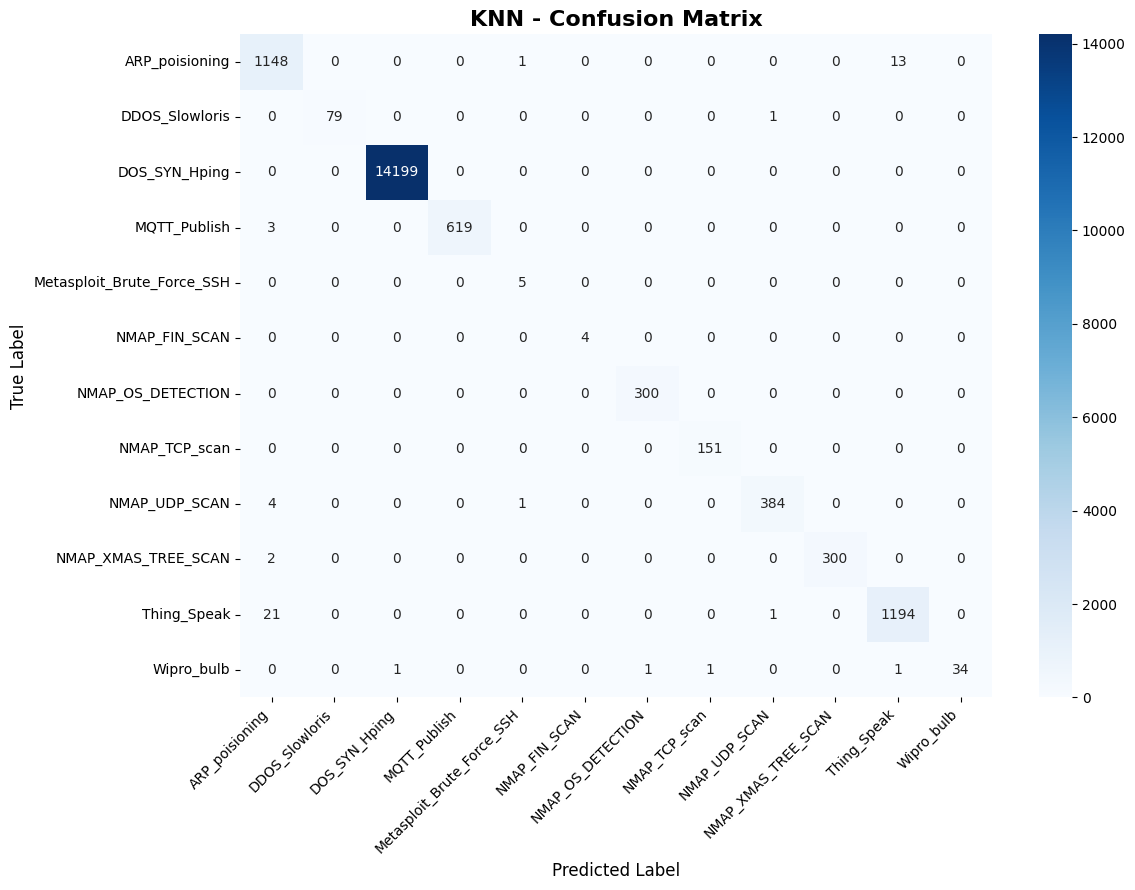

✓ Confusion matrix saved: /content/edgeguard_KNN/knn_confusion_matrix.png

Generating normalized confusion matrix...


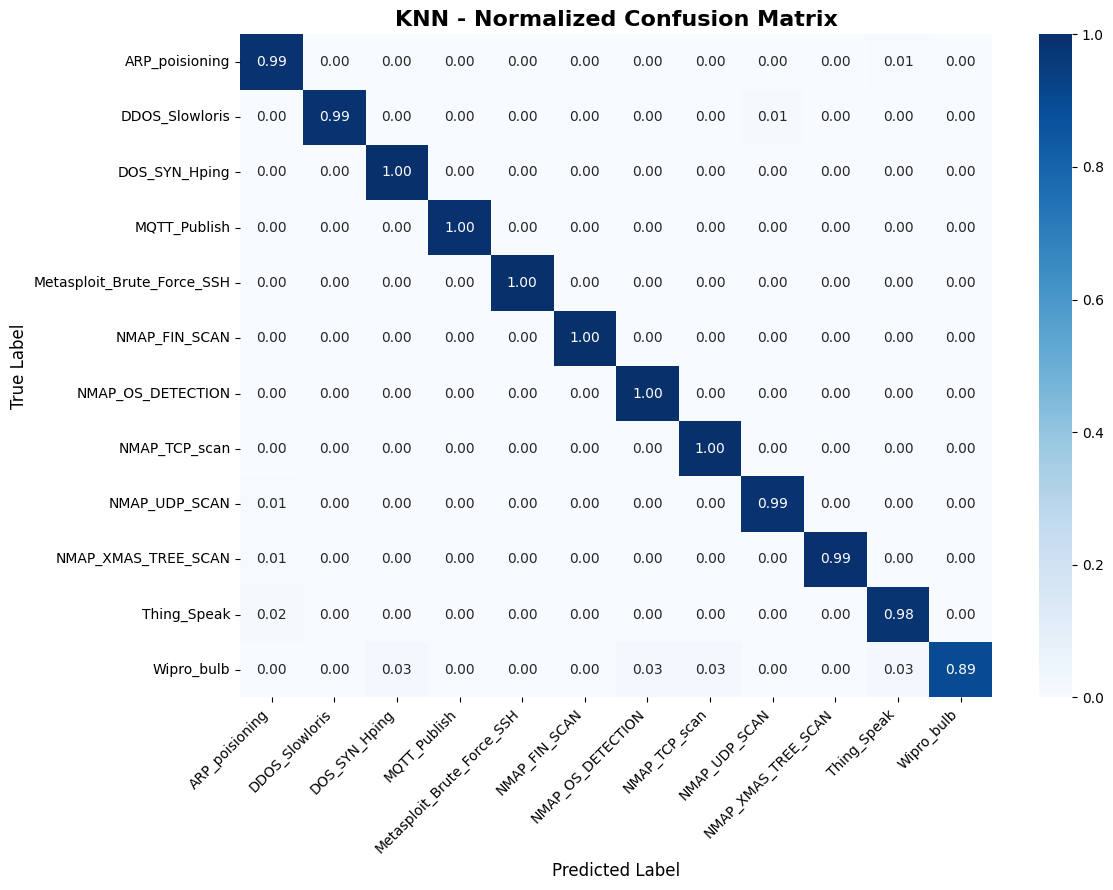

✓ Normalized confusion matrix saved: /content/edgeguard_KNN/knn_normalized_confusion_matrix.png

Generating performance graph...


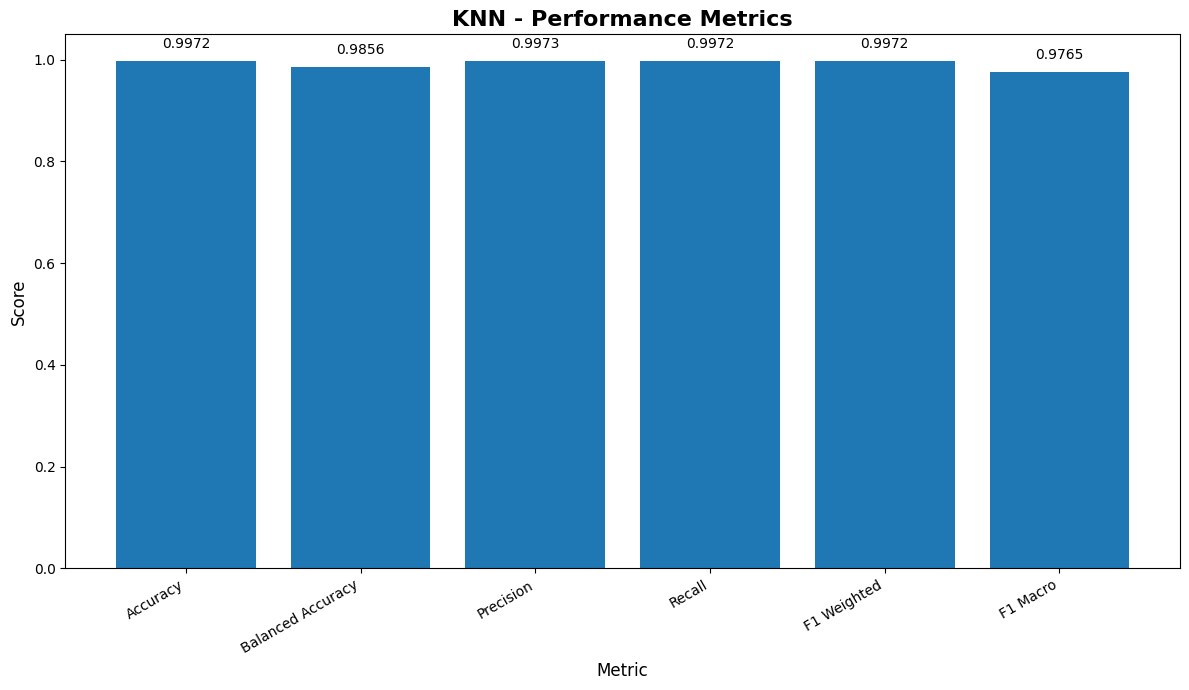

✓ Performance graph saved: /content/edgeguard_KNN/knn_performance_metrics.png

14. SAVING METRICS
✓ Metrics saved: /content/edgeguard_KNN/knn_metrics.csv

Saving test predictions...
✓ Predictions saved: /content/edgeguard_KNN/knn_predictions.csv

Saving trained KNN model...
✓ Model saved: /content/edgeguard_KNN/knn_bundle.joblib
✓ Summary saved: /content/edgeguard_KNN/knn_summary.txt

KNN PIPELINE COMPLETED SUCCESSFULLY

Generated files:
✓ attack_type_distribution.png                           269.02 KB
✓ knn_bundle.joblib                                      56569.54 KB
✓ knn_classification_report.csv                          1.01 KB
✓ knn_confusion_matrix.png                               420.67 KB
✓ knn_metrics.csv                                        0.37 KB
✓ knn_normalized_confusion_matrix.png                    460.59 KB
✓ knn_per_class_results.csv                              0.75 KB
✓ knn_performance_metrics.png                            158.91 KB
✓ knn_predictions.csv     

In [10]:
# ================================================================
# EDGEGUARD - KNN COMPLETE PIPELINE
# Dataset: Friday.csv
# Target: Attack_type
# Split: 70% Train / 15% Validation / 15% Test
#
# OUTPUT:
# - Confusion Matrix PNG
# - Normalized Confusion Matrix PNG
# - Attack Distribution PNG
# - Performance Metrics PNG
# - Classification Report CSV
# - Metrics CSV
# - Predictions CSV
# - Trained Model Bundle
# ================================================================


# ================================================================
# 0. IMPORT LIBRARIES
# ================================================================

import os
import time
import joblib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OrdinalEncoder,
    MinMaxScaler
)

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


warnings.filterwarnings("ignore")


# ================================================================
# 1. CONFIGURATION
# ================================================================

RANDOM_STATE = 42

CSV_PATH = "/content/friday.csv"

TARGET = "Attack_type"

KNN_OUTPUT = "/content/edgeguard_KNN"

os.makedirs(
    KNN_OUTPUT,
    exist_ok=True
)

print("=" * 70)
print("EDGEGUARD - KNN PIPELINE")
print("=" * 70)

print("Dataset :", CSV_PATH)
print("Target  :", TARGET)
print("Output  :", KNN_OUTPUT)


# ================================================================
# 2. LOAD DATA
# ================================================================

print("\n" + "=" * 70)
print("1. LOADING DATA")
print("=" * 70)

df_knn = pd.read_csv(
    CSV_PATH,
    low_memory=False
)

print(
    "Original shape:",
    df_knn.shape
)


# ================================================================
# 3. BASIC CLEANING
# ================================================================

print("\n" + "=" * 70)
print("2. DATA CLEANING")
print("=" * 70)


# Remove CSV index column
if "Unnamed: 0" in df_knn.columns:

    df_knn = df_knn.drop(
        columns=["Unnamed: 0"]
    )

    print("Removed: Unnamed: 0")


# Check target
if TARGET not in df_knn.columns:

    raise ValueError(
        f"Target column '{TARGET}' not found in dataset."
    )


# Remove missing target rows
before_drop = len(df_knn)

df_knn = df_knn.dropna(
    subset=[TARGET]
).copy()

after_drop = len(df_knn)

print(
    "Rows removed due to missing target:",
    before_drop - after_drop
)

print(
    "Shape after cleaning:",
    df_knn.shape
)


# ================================================================
# 4. TARGET DISTRIBUTION
# ================================================================

print("\n" + "=" * 70)
print("3. TARGET DISTRIBUTION")
print("=" * 70)


target_distribution_knn = (
    df_knn[TARGET]
    .value_counts()
)

print(
    target_distribution_knn
)


CLASS_NAMES_KNN = sorted(
    df_knn[TARGET].unique()
)


print(
    "\nNumber of classes:",
    len(CLASS_NAMES_KNN)
)

print(
    "Classes:",
    CLASS_NAMES_KNN
)


# ================================================================
# 5. TARGET DISTRIBUTION GRAPH
# ================================================================

print(
    "\nGenerating attack distribution graph..."
)


plt.figure(
    figsize=(12, 7)
)


target_distribution_knn.plot(
    kind="bar"
)


plt.title(
    "Attack Type Distribution",
    fontsize=16,
    fontweight="bold"
)


plt.xlabel(
    "Attack Type",
    fontsize=12
)


plt.ylabel(
    "Number of Samples",
    fontsize=12
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.tight_layout()


distribution_path = os.path.join(
    KNN_OUTPUT,
    "attack_type_distribution.png"
)


plt.savefig(
    distribution_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()


print(
    "✓ Saved:",
    distribution_path
)


# ================================================================
# 6. FEATURES / TARGET
# ================================================================

print("\n" + "=" * 70)
print("4. FEATURES / TARGET")
print("=" * 70)


X_knn = df_knn.drop(
    columns=[TARGET]
)


y_knn = df_knn[TARGET]


print(
    "Number of samples:",
    X_knn.shape[0]
)


print(
    "Number of features:",
    X_knn.shape[1]
)


# ================================================================
# 7. TRAIN / VALIDATION / TEST SPLIT
# ================================================================

print("\n" + "=" * 70)
print("5. DATA SPLIT")
print("=" * 70)


# 70% Train
# 30% temporary

X_train_knn, X_temp_knn, y_train_knn, y_temp_knn = train_test_split(

    X_knn,

    y_knn,

    test_size=0.30,

    stratify=y_knn,

    random_state=RANDOM_STATE

)


# Remaining 30%
# 15% Validation
# 15% Test

X_val_knn, X_test_knn, y_val_knn, y_test_knn = train_test_split(

    X_temp_knn,

    y_temp_knn,

    test_size=0.50,

    stratify=y_temp_knn,

    random_state=RANDOM_STATE

)


print(
    "Total      :",
    len(X_knn)
)


print(
    "Train      :",
    len(X_train_knn)
)


print(
    "Validation :",
    len(X_val_knn)
)


print(
    "Test       :",
    len(X_test_knn)
)


# ================================================================
# 8. FEATURE TYPES
# ================================================================

print("\n" + "=" * 70)
print("6. FEATURE TYPES")
print("=" * 70)


numeric_features_knn = [

    col

    for col in X_train_knn.columns

    if pd.api.types.is_numeric_dtype(
        X_train_knn[col]
    )

]


categorical_features_knn = [

    col

    for col in X_train_knn.columns

    if col not in numeric_features_knn

]


print(
    "Numerical features:",
    len(numeric_features_knn)
)


print(
    "Categorical features:",
    len(categorical_features_knn)
)


if len(categorical_features_knn) > 0:

    print(
        "Categorical:",
        categorical_features_knn
    )


# ================================================================
# 9. PREPROCESSING
# ================================================================

print("\n" + "=" * 70)
print("7. PREPROCESSING")
print("=" * 70)


# Numerical pipeline
numeric_pipeline_knn = Pipeline([

    (
        "imputer",

        SimpleImputer(
            strategy="median"
        )

    ),

    (
        "scaler",

        MinMaxScaler()

    )

])


# Categorical pipeline
categorical_pipeline_knn = Pipeline([

    (
        "imputer",

        SimpleImputer(
            strategy="most_frequent"
        )

    ),

    (
        "encoder",

        OrdinalEncoder(

            handle_unknown="use_encoded_value",

            unknown_value=-1

        )

    )

])


# Combined preprocessor
preprocessor_knn = ColumnTransformer([

    (
        "numeric",

        numeric_pipeline_knn,

        numeric_features_knn

    ),

    (
        "categorical",

        categorical_pipeline_knn,

        categorical_features_knn

    )

])


print(
    "Fitting preprocessing..."
)


# Fit on training
X_train_knn_processed = (

    preprocessor_knn

    .fit_transform(
        X_train_knn
    )

)


# Validation
X_val_knn_processed = (

    preprocessor_knn

    .transform(
        X_val_knn
    )

)


# Test
X_test_knn_processed = (

    preprocessor_knn

    .transform(
        X_test_knn
    )

)


print(
    "Processed train:",
    X_train_knn_processed.shape
)


print(
    "Processed validation:",
    X_val_knn_processed.shape
)


print(
    "Processed test:",
    X_test_knn_processed.shape
)


# ================================================================
# 10. KNN MODEL
# ================================================================

print("\n" + "=" * 70)
print("8. KNN TRAINING")
print("=" * 70)


# Number of neighbors
K_NEIGHBORS = 5


knn_model = KNeighborsClassifier(

    n_neighbors=K_NEIGHBORS,

    weights="distance",

    metric="minkowski",

    p=2,

    n_jobs=-1

)


print(
    "K:",
    K_NEIGHBORS
)

print(
    "Weights: distance"
)

print(
    "Metric: Euclidean distance"
)


# Start training timer
start_train_knn = time.time()


# Train
knn_model.fit(

    X_train_knn_processed,

    y_train_knn

)


# Training time
knn_training_time = (

    time.time()
    - start_train_knn

)


print(
    f"Training time: "
    f"{knn_training_time:.4f} seconds"
)


# ================================================================
# 11. VALIDATION PREDICTION
# ================================================================

print("\n" + "=" * 70)
print("9. VALIDATION")
print("=" * 70)


knn_val_predictions = knn_model.predict(

    X_val_knn_processed

)


knn_val_accuracy = accuracy_score(

    y_val_knn,

    knn_val_predictions

)


print(
    f"Validation Accuracy: "
    f"{knn_val_accuracy:.4f}"
)


# ================================================================
# 12. TEST PREDICTION
# ================================================================

print("\n" + "=" * 70)
print("10. TEST PREDICTION")
print("=" * 70)


start_test_knn = time.time()


# Predictions
knn_predictions = knn_model.predict(

    X_test_knn_processed

)


# Probabilities
knn_probabilities = (

    knn_model.predict_proba(

        X_test_knn_processed

    )

)


# Inference time
knn_inference_time = (

    time.time()
    - start_test_knn

)


avg_inference_ms = (

    knn_inference_time
    / len(X_test_knn)
    * 1000

)


print(
    f"Test inference time: "
    f"{knn_inference_time:.4f} seconds"
)


print(
    f"Average inference/sample: "
    f"{avg_inference_ms:.6f} ms"
)


# ================================================================
# 13. EVALUATION
# ================================================================

print("\n" + "=" * 70)
print("11. KNN RESULTS")
print("=" * 70)


knn_accuracy = accuracy_score(

    y_test_knn,

    knn_predictions

)


knn_balanced_accuracy = (

    balanced_accuracy_score(

        y_test_knn,

        knn_predictions

    )

)


knn_precision = precision_score(

    y_test_knn,

    knn_predictions,

    average="weighted",

    zero_division=0

)


knn_recall = recall_score(

    y_test_knn,

    knn_predictions,

    average="weighted",

    zero_division=0

)


knn_f1_weighted = f1_score(

    y_test_knn,

    knn_predictions,

    average="weighted",

    zero_division=0

)


knn_f1_macro = f1_score(

    y_test_knn,

    knn_predictions,

    average="macro",

    zero_division=0

)


print(
    f"Accuracy           : "
    f"{knn_accuracy:.4f}"
)


print(
    f"Balanced Accuracy  : "
    f"{knn_balanced_accuracy:.4f}"
)


print(
    f"Precision Weighted : "
    f"{knn_precision:.4f}"
)


print(
    f"Recall Weighted    : "
    f"{knn_recall:.4f}"
)


print(
    f"F1 Weighted        : "
    f"{knn_f1_weighted:.4f}"
)


print(
    f"F1 Macro           : "
    f"{knn_f1_macro:.4f}"
)


# ================================================================
# 14. CLASSIFICATION REPORT
# ================================================================

print("\n" + "=" * 70)
print("12. CLASSIFICATION REPORT")
print("=" * 70)


print(

    classification_report(

        y_test_knn,

        knn_predictions,

        labels=CLASS_NAMES_KNN,

        zero_division=0

    )

)


# Create report dictionary
knn_report = classification_report(

    y_test_knn,

    knn_predictions,

    labels=CLASS_NAMES_KNN,

    output_dict=True,

    zero_division=0

)


knn_report_df = pd.DataFrame(
    knn_report
).transpose()


# Save classification report
report_path = os.path.join(

    KNN_OUTPUT,

    "knn_classification_report.csv"

)


knn_report_df.to_csv(

    report_path

)


print(
    "✓ Classification report saved:",
    report_path
)


# ================================================================
# 15. CONFUSION MATRIX
# ================================================================

print("\n" + "=" * 70)
print("13. CONFUSION MATRIX")
print("=" * 70)


knn_cm = confusion_matrix(

    y_test_knn,

    knn_predictions,

    labels=CLASS_NAMES_KNN

)


print(
    "\nConfusion Matrix:"
)


print(
    knn_cm
)


plt.figure(

    figsize=(12, 9)

)


sns.heatmap(

    knn_cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=CLASS_NAMES_KNN,

    yticklabels=CLASS_NAMES_KNN,

    cbar=True

)


plt.title(

    "KNN - Confusion Matrix",

    fontsize=16,

    fontweight="bold"

)


plt.xlabel(

    "Predicted Label",

    fontsize=12

)


plt.ylabel(

    "True Label",

    fontsize=12

)


plt.xticks(

    rotation=45,

    ha="right"

)


plt.yticks(

    rotation=0

)


plt.tight_layout()


cm_path = os.path.join(

    KNN_OUTPUT,

    "knn_confusion_matrix.png"

)


plt.savefig(

    cm_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Confusion matrix saved:",
    cm_path
)


# ================================================================
# 16. NORMALIZED CONFUSION MATRIX
# ================================================================

print(
    "\nGenerating normalized confusion matrix..."
)


knn_cm_normalized = (

    knn_cm.astype(float)

    / knn_cm.sum(

        axis=1,

        keepdims=True

    )

)


# Avoid NaN
knn_cm_normalized = np.nan_to_num(

    knn_cm_normalized

)


plt.figure(

    figsize=(12, 9)

)


sns.heatmap(

    knn_cm_normalized,

    annot=True,

    fmt=".2f",

    cmap="Blues",

    xticklabels=CLASS_NAMES_KNN,

    yticklabels=CLASS_NAMES_KNN,

    vmin=0,

    vmax=1

)


plt.title(

    "KNN - Normalized Confusion Matrix",

    fontsize=16,

    fontweight="bold"

)


plt.xlabel(

    "Predicted Label",

    fontsize=12

)


plt.ylabel(

    "True Label",

    fontsize=12

)


plt.xticks(

    rotation=45,

    ha="right"

)


plt.yticks(

    rotation=0

)


plt.tight_layout()


normalized_cm_path = os.path.join(

    KNN_OUTPUT,

    "knn_normalized_confusion_matrix.png"

)


plt.savefig(

    normalized_cm_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Normalized confusion matrix saved:",
    normalized_cm_path
)


# ================================================================
# 17. MODEL PERFORMANCE GRAPH
# ================================================================

print(
    "\nGenerating performance graph..."
)


performance_metrics = {

    "Accuracy":
        knn_accuracy,

    "Balanced Accuracy":
        knn_balanced_accuracy,

    "Precision":
        knn_precision,

    "Recall":
        knn_recall,

    "F1 Weighted":
        knn_f1_weighted,

    "F1 Macro":
        knn_f1_macro

}


plt.figure(

    figsize=(12, 7)

)


bars = plt.bar(

    performance_metrics.keys(),

    performance_metrics.values()

)


plt.ylim(

    0,

    1.05

)


plt.ylabel(

    "Score",

    fontsize=12

)


plt.xlabel(

    "Metric",

    fontsize=12

)


plt.title(

    "KNN - Performance Metrics",

    fontsize=16,

    fontweight="bold"

)


plt.xticks(

    rotation=30,

    ha="right"

)


# Add values
for bar, value in zip(

    bars,

    performance_metrics.values()

):

    plt.text(

        bar.get_x()
        + bar.get_width() / 2,

        value + 0.02,

        f"{value:.4f}",

        ha="center",

        va="bottom",

        fontsize=10

    )


plt.tight_layout()


performance_graph_path = os.path.join(

    KNN_OUTPUT,

    "knn_performance_metrics.png"

)


plt.savefig(

    performance_graph_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Performance graph saved:",
    performance_graph_path
)


# ================================================================
# 18. SAVE METRICS
# ================================================================

print("\n" + "=" * 70)
print("14. SAVING METRICS")
print("=" * 70)


knn_results = pd.DataFrame([{

    "Model":
        "KNN",

    "K_Neighbors":
        K_NEIGHBORS,

    "Accuracy":
        knn_accuracy,

    "Balanced_Accuracy":
        knn_balanced_accuracy,

    "Precision_Weighted":
        knn_precision,

    "Recall_Weighted":
        knn_recall,

    "F1_Weighted":
        knn_f1_weighted,

    "F1_Macro":
        knn_f1_macro,

    "Validation_Accuracy":
        knn_val_accuracy,

    "Training_Time_sec":
        knn_training_time,

    "Inference_Time_sec":
        knn_inference_time,

    "Inference_Per_Sample_ms":
        avg_inference_ms

}])


metrics_path = os.path.join(

    KNN_OUTPUT,

    "knn_metrics.csv"

)


knn_results.to_csv(

    metrics_path,

    index=False

)


print(
    "✓ Metrics saved:",
    metrics_path
)


# ================================================================
# 19. SAVE TEST PREDICTIONS
# ================================================================

print(
    "\nSaving test predictions..."
)


prediction_df = pd.DataFrame({

    "Actual_Label":
        y_test_knn.values,

    "Predicted_Label":
        knn_predictions,

    "Confidence":
        knn_probabilities.max(
            axis=1
        )

})


prediction_path = os.path.join(

    KNN_OUTPUT,

    "knn_predictions.csv"

)


prediction_df.to_csv(

    prediction_path,

    index=False

)


print(
    "✓ Predictions saved:",
    prediction_path
)


# ================================================================
# 20. SAVE MODEL BUNDLE
# ================================================================

print(
    "\nSaving trained KNN model..."
)


model_path = os.path.join(

    KNN_OUTPUT,

    "knn_bundle.joblib"

)


joblib.dump(

    {

        "model":
            knn_model,

        "preprocessor":
            preprocessor_knn,

        "features":
            X_knn.columns.tolist(),

        "classes":
            CLASS_NAMES_KNN,

        "k_neighbors":
            K_NEIGHBORS

    },

    model_path

)


print(
    "✓ Model saved:",
    model_path
)


# ================================================================
# 21. SAVE TEXT SUMMARY
# ================================================================

summary_path = os.path.join(

    KNN_OUTPUT,

    "knn_summary.txt"

)


with open(

    summary_path,

    "w"

) as f:

    f.write(
        "EDGEGUARD - KNN RESULTS\n"
    )

    f.write(
        "=" * 60 + "\n\n"
    )

    f.write(
        f"Dataset: {CSV_PATH}\n"
    )

    f.write(
        f"Target: {TARGET}\n"
    )

    f.write(
        f"K Neighbors: {K_NEIGHBORS}\n\n"
    )

    f.write(
        "DATA SPLIT\n"
    )

    f.write(
        f"Total: {len(X_knn)}\n"
    )

    f.write(
        f"Train: {len(X_train_knn)}\n"
    )

    f.write(
        f"Validation: {len(X_val_knn)}\n"
    )

    f.write(
        f"Test: {len(X_test_knn)}\n\n"
    )

    f.write(
        "MODEL PERFORMANCE\n"
    )

    f.write(
        f"Accuracy: {knn_accuracy:.4f}\n"
    )

    f.write(
        f"Balanced Accuracy: "
        f"{knn_balanced_accuracy:.4f}\n"
    )

    f.write(
        f"Precision Weighted: "
        f"{knn_precision:.4f}\n"
    )

    f.write(
        f"Recall Weighted: "
        f"{knn_recall:.4f}\n"
    )

    f.write(
        f"F1 Weighted: "
        f"{knn_f1_weighted:.4f}\n"
    )

    f.write(
        f"F1 Macro: "
        f"{knn_f1_macro:.4f}\n"
    )

    f.write(
        f"Validation Accuracy: "
        f"{knn_val_accuracy:.4f}\n"
    )

    f.write(
        f"Training Time: "
        f"{knn_training_time:.4f} sec\n"
    )

    f.write(
        f"Inference Time: "
        f"{knn_inference_time:.4f} sec\n"
    )

    f.write(
        f"Average Inference: "
        f"{avg_inference_ms:.6f} ms/sample\n"
    )


print(
    "✓ Summary saved:",
    summary_path
)


# ================================================================
# 22. FINAL OUTPUT LIST
# ================================================================

print("\n" + "=" * 70)
print("KNN PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 70)


print(
    "\nGenerated files:"
)


for file_name in sorted(

    os.listdir(
        KNN_OUTPUT
    )

):

    file_path = os.path.join(

        KNN_OUTPUT,

        file_name

    )


    if os.path.isfile(
        file_path
    ):

        size_kb = (

            os.path.getsize(
                file_path
            )
            / 1024

        )

        print(

            f"✓ {file_name:<55}"
            f"{size_kb:.2f} KB"

        )


print(
    "\nOutput directory:"
)


print(
    KNN_OUTPUT
)


print(
    "\n✓ KNN pipeline completed successfully."
)

EDGEGUARD - FINAL MODEL COMPARISON

✓ Random Forest results loaded
✓ XGBoost results loaded
✓ KNN results loaded

FINAL MODEL COMPARISON


,Model,Accuracy,Balanced_Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,F1_Macro,Training_Time_sec,Inference_Time_sec,Inference_Per_Sample_ms
0,Random Forest,0.9982,0.9757,0.9982,0.9982,0.9982,0.9711,8.4189,0.4070,0.022041
1,XGBoost,0.9984,0.9772,0.9984,0.9984,0.9984,0.9725,64.3421,1.2323,0.066726
2,KNN,0.9972,0.9856,0.9973,0.9972,0.9972,0.9765,0.1020,36.6760,1.985923



✓ Comparison CSV saved:
/content/edgeguard_Final_Comparison/final_model_comparison.csv

Generating classification performance graph...


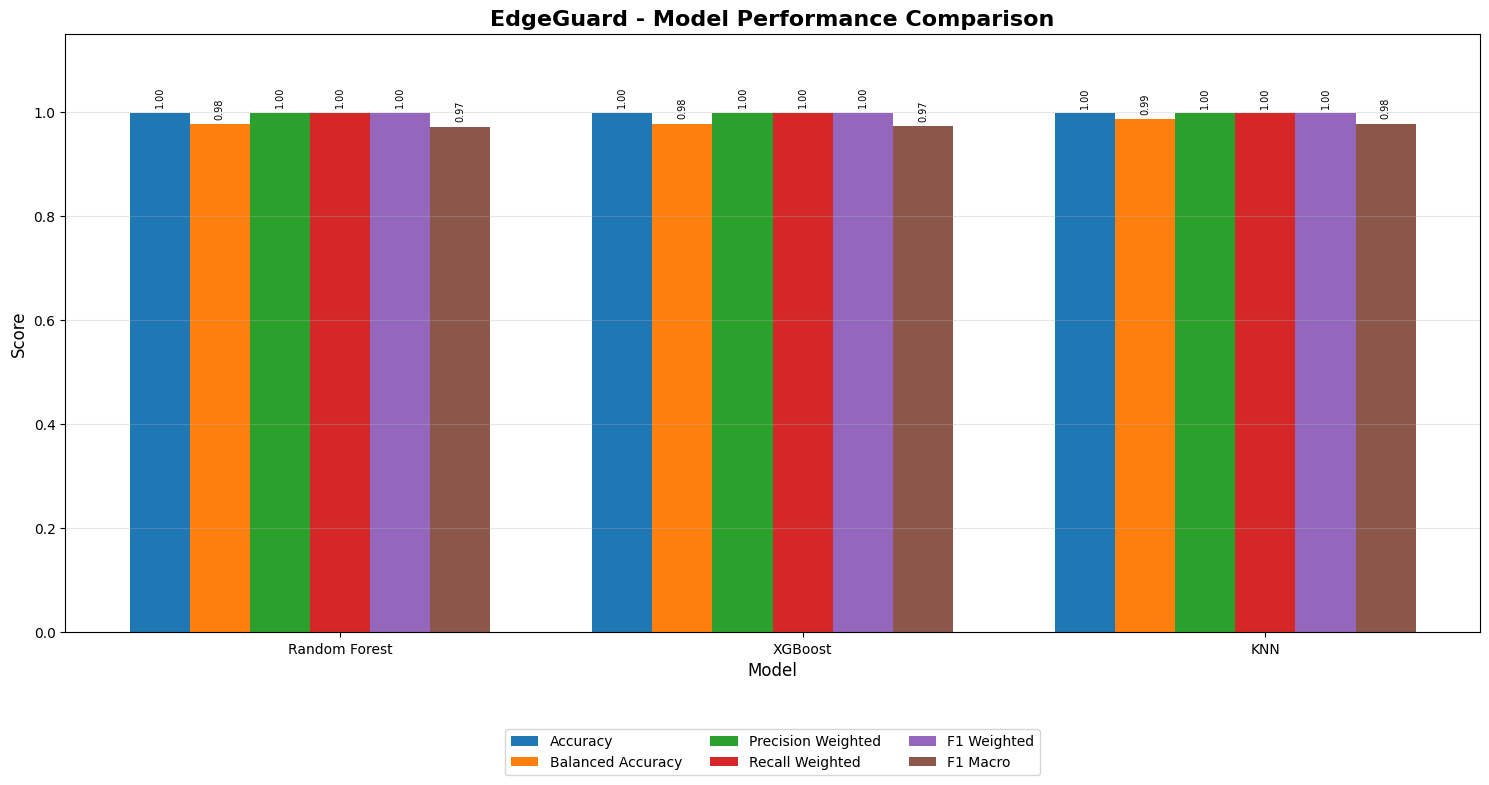

✓ Performance comparison saved:
/content/edgeguard_Final_Comparison/model_performance_comparison.png


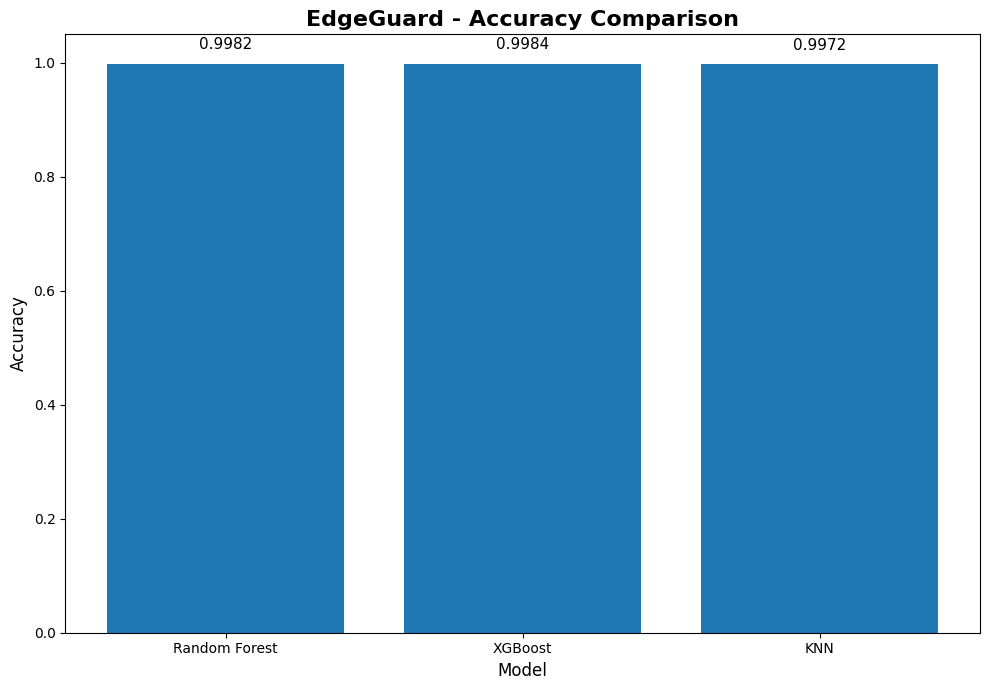

✓ Accuracy graph saved:
/content/edgeguard_Final_Comparison/accuracy_comparison.png


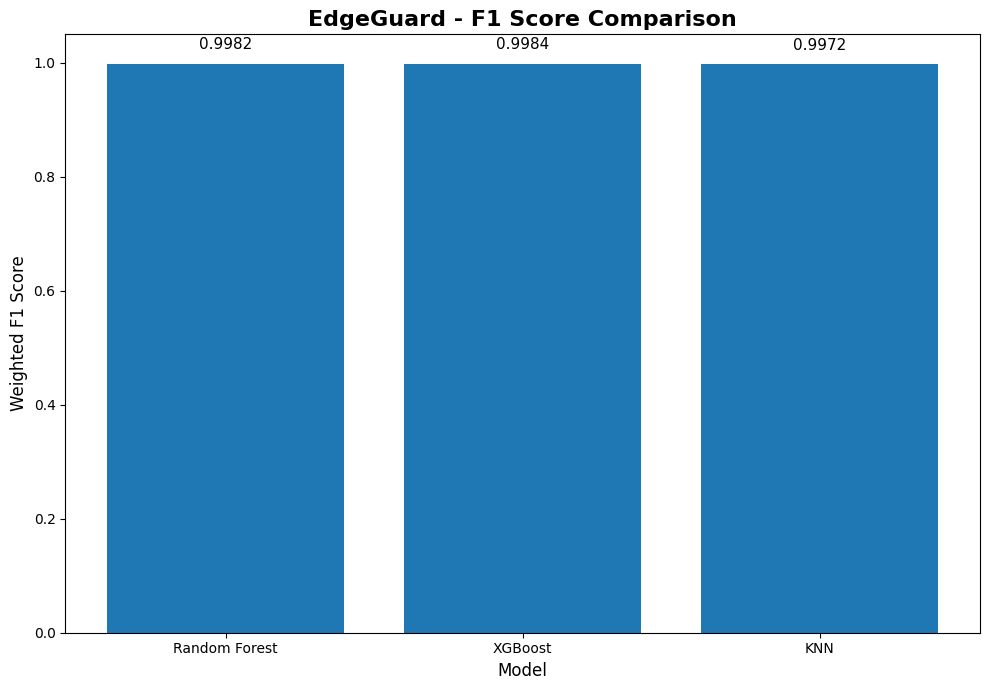

✓ F1 graph saved:
/content/edgeguard_Final_Comparison/f1_comparison.png


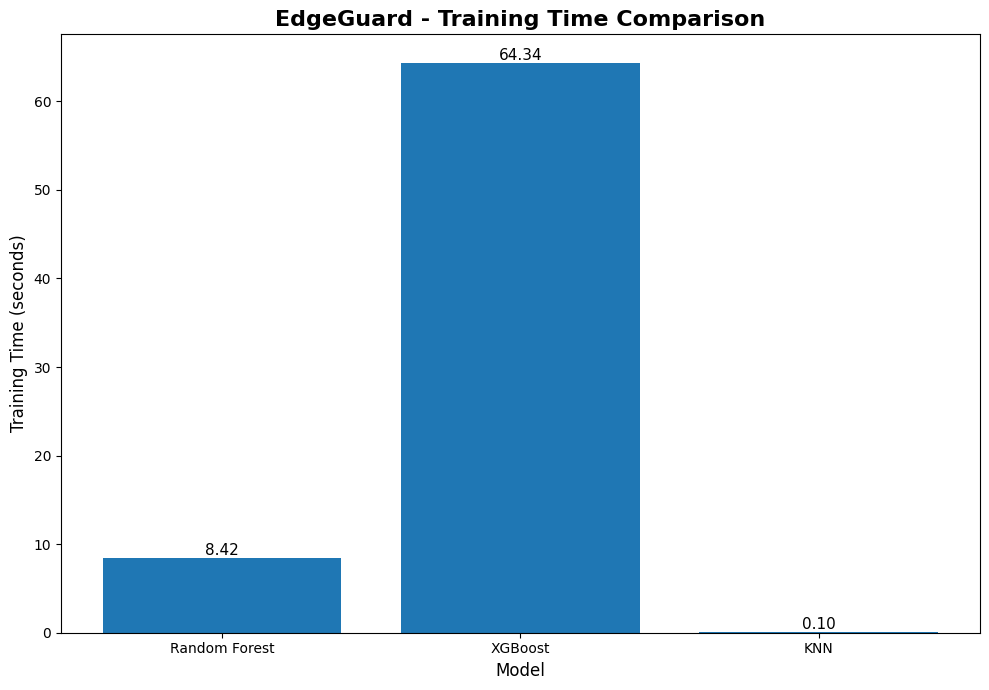

✓ Training time graph saved:
/content/edgeguard_Final_Comparison/training_time_comparison.png


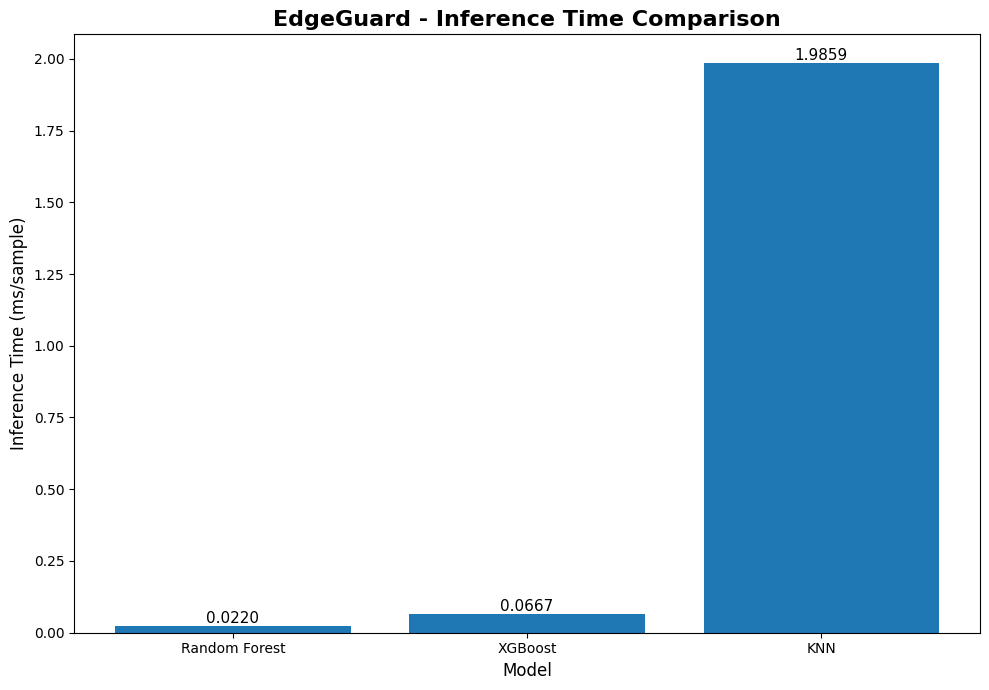

✓ Inference time graph saved:
/content/edgeguard_Final_Comparison/inference_time_comparison.png
✓ Text report saved:
/content/edgeguard_Final_Comparison/final_model_comparison.txt

FINAL COMPARISON COMPLETED

Generated files:
✓ accuracy_comparison.png                           97.15 KB
✓ f1_comparison.png                                 102.42 KB
✓ final_model_comparison.csv                        0.67 KB
✓ final_model_comparison.txt                        0.86 KB
✓ inference_time_comparison.png                     124.75 KB
✓ model_performance_comparison.png                  164.97 KB
✓ training_time_comparison.png                      106.35 KB

Output directory:
/content/edgeguard_Final_Comparison

✓ EdgeGuard final comparison completed.


In [11]:
# ================================================================
# EDGEGUARD - FINAL RESULT COMPARISON
# Random Forest vs XGBoost vs KNN
# ================================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# ================================================================
# 1. OUTPUT DIRECTORIES
# ================================================================

RF_OUTPUT = "/content/edgeguard_RF"
XGB_OUTPUT = "/content/edgeguard_XGBoost"
KNN_OUTPUT = "/content/edgeguard_KNN"

COMPARISON_OUTPUT = "/content/edgeguard_Final_Comparison"

os.makedirs(
    COMPARISON_OUTPUT,
    exist_ok=True
)


# ================================================================
# 2. LOAD RESULTS
# ================================================================

print("=" * 70)
print("EDGEGUARD - FINAL MODEL COMPARISON")
print("=" * 70)


rf_file = os.path.join(
    RF_OUTPUT,
    "random_forest_metrics.csv"
)

xgb_file = os.path.join(
    XGB_OUTPUT,
    "xgboost_metrics.csv"
)

knn_file = os.path.join(
    KNN_OUTPUT,
    "knn_metrics.csv"
)


# Check files
for file_path in [
    rf_file,
    xgb_file,
    knn_file
]:

    if not os.path.exists(file_path):

        raise FileNotFoundError(
            f"Result file not found:\n{file_path}\n"
            "Please run the corresponding model first."
        )


# Read CSVs
rf_results = pd.read_csv(
    rf_file
)

xgb_results = pd.read_csv(
    xgb_file
)

knn_results = pd.read_csv(
    knn_file
)


print("\n✓ Random Forest results loaded")
print("✓ XGBoost results loaded")
print("✓ KNN results loaded")


# ================================================================
# 3. COMBINE RESULTS
# ================================================================

comparison_df = pd.concat(

    [
        rf_results,
        xgb_results,
        knn_results
    ],

    ignore_index=True

)


# Keep important columns
comparison_columns = [

    "Model",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision_Weighted",
    "Recall_Weighted",
    "F1_Weighted",
    "F1_Macro",
    "Training_Time_sec",
    "Inference_Time_sec",
    "Inference_Per_Sample_ms"

]


# KNN has additional K column, so only select
# columns that exist
available_columns = [

    col

    for col in comparison_columns

    if col in comparison_df.columns

]


comparison_df = comparison_df[
    available_columns
]


# ================================================================
# 4. DISPLAY FINAL COMPARISON TABLE
# ================================================================

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)


display(
    comparison_df.style.format({

        "Accuracy": "{:.4f}",

        "Balanced_Accuracy": "{:.4f}",

        "Precision_Weighted": "{:.4f}",

        "Recall_Weighted": "{:.4f}",

        "F1_Weighted": "{:.4f}",

        "F1_Macro": "{:.4f}",

        "Training_Time_sec": "{:.4f}",

        "Inference_Time_sec": "{:.4f}",

        "Inference_Per_Sample_ms": "{:.6f}"

    })
)


# ================================================================
# 5. SAVE COMPARISON CSV
# ================================================================

comparison_csv_path = os.path.join(

    COMPARISON_OUTPUT,

    "final_model_comparison.csv"

)


comparison_df.to_csv(

    comparison_csv_path,

    index=False

)


print(
    "\n✓ Comparison CSV saved:"
)

print(
    comparison_csv_path
)


# ================================================================
# 6. CLASSIFICATION PERFORMANCE GRAPH
# ================================================================

print(
    "\nGenerating classification performance graph..."
)


metrics = [

    "Accuracy",

    "Balanced_Accuracy",

    "Precision_Weighted",

    "Recall_Weighted",

    "F1_Weighted",

    "F1_Macro"

]


model_names = comparison_df[
    "Model"
].tolist()


x = np.arange(
    len(model_names)
)


width = 0.13


plt.figure(
    figsize=(15, 8)
)


for i, metric in enumerate(metrics):

    values = comparison_df[
        metric
    ].values

    bars = plt.bar(

        x + (
            i - len(metrics) / 2
        ) * width,

        values,

        width,

        label=metric.replace(
            "_",
            " "
        )

    )

    # Add values above bars
    for bar, value in zip(
        bars,
        values
    ):

        plt.text(

            bar.get_x()
            + bar.get_width() / 2,

            value + 0.01,

            f"{value:.2f}",

            ha="center",

            va="bottom",

            fontsize=7,

            rotation=90

        )


plt.xlabel(
    "Model",
    fontsize=12
)


plt.ylabel(
    "Score",
    fontsize=12
)


plt.title(

    "EdgeGuard - Model Performance Comparison",

    fontsize=16,

    fontweight="bold"

)


plt.xticks(
    x,
    model_names
)


plt.ylim(
    0,
    1.15
)


plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3
)


plt.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()


performance_comparison_path = os.path.join(

    COMPARISON_OUTPUT,

    "model_performance_comparison.png"

)


plt.savefig(

    performance_comparison_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Performance comparison saved:"
)

print(
    performance_comparison_path
)


# ================================================================
# 7. ACCURACY COMPARISON
# ================================================================

plt.figure(
    figsize=(10, 7)
)


bars = plt.bar(

    comparison_df["Model"],

    comparison_df["Accuracy"]

)


plt.ylabel(
    "Accuracy",
    fontsize=12
)


plt.xlabel(
    "Model",
    fontsize=12
)


plt.title(

    "EdgeGuard - Accuracy Comparison",

    fontsize=16,

    fontweight="bold"

)


plt.ylim(
    0,
    1.05
)


for bar, value in zip(

    bars,

    comparison_df["Accuracy"]

):

    plt.text(

        bar.get_x()
        + bar.get_width() / 2,

        value + 0.02,

        f"{value:.4f}",

        ha="center",

        va="bottom",

        fontsize=11

    )


plt.tight_layout()


accuracy_path = os.path.join(

    COMPARISON_OUTPUT,

    "accuracy_comparison.png"

)


plt.savefig(

    accuracy_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Accuracy graph saved:"
)

print(
    accuracy_path
)


# ================================================================
# 8. F1 SCORE COMPARISON
# ================================================================

plt.figure(
    figsize=(10, 7)
)


bars = plt.bar(

    comparison_df["Model"],

    comparison_df["F1_Weighted"]

)


plt.ylabel(
    "Weighted F1 Score",
    fontsize=12
)


plt.xlabel(
    "Model",
    fontsize=12
)


plt.title(

    "EdgeGuard - F1 Score Comparison",

    fontsize=16,

    fontweight="bold"

)


plt.ylim(
    0,
    1.05
)


for bar, value in zip(

    bars,

    comparison_df["F1_Weighted"]

):

    plt.text(

        bar.get_x()
        + bar.get_width() / 2,

        value + 0.02,

        f"{value:.4f}",

        ha="center",

        va="bottom",

        fontsize=11

    )


plt.tight_layout()


f1_path = os.path.join(

    COMPARISON_OUTPUT,

    "f1_comparison.png"

)


plt.savefig(

    f1_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ F1 graph saved:"
)

print(
    f1_path
)


# ================================================================
# 9. TRAINING TIME COMPARISON
# ================================================================

plt.figure(
    figsize=(10, 7)
)


bars = plt.bar(

    comparison_df["Model"],

    comparison_df["Training_Time_sec"]

)


plt.ylabel(
    "Training Time (seconds)",
    fontsize=12
)


plt.xlabel(
    "Model",
    fontsize=12
)


plt.title(

    "EdgeGuard - Training Time Comparison",

    fontsize=16,

    fontweight="bold"

)


for bar, value in zip(

    bars,

    comparison_df["Training_Time_sec"]

):

    plt.text(

        bar.get_x()
        + bar.get_width() / 2,

        value,

        f"{value:.2f}",

        ha="center",

        va="bottom",

        fontsize=11

    )


plt.tight_layout()


training_time_path = os.path.join(

    COMPARISON_OUTPUT,

    "training_time_comparison.png"

)


plt.savefig(

    training_time_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Training time graph saved:"
)

print(
    training_time_path
)


# ================================================================
# 10. INFERENCE TIME COMPARISON
# ================================================================

plt.figure(
    figsize=(10, 7)
)


bars = plt.bar(

    comparison_df["Model"],

    comparison_df[
        "Inference_Per_Sample_ms"
    ]

)


plt.ylabel(

    "Inference Time (ms/sample)",

    fontsize=12

)


plt.xlabel(
    "Model",
    fontsize=12
)


plt.title(

    "EdgeGuard - Inference Time Comparison",

    fontsize=16,

    fontweight="bold"

)


for bar, value in zip(

    bars,

    comparison_df[
        "Inference_Per_Sample_ms"
    ]

):

    plt.text(

        bar.get_x()
        + bar.get_width() / 2,

        value,

        f"{value:.4f}",

        ha="center",

        va="bottom",

        fontsize=11

    )


plt.tight_layout()


inference_path = os.path.join(

    COMPARISON_OUTPUT,

    "inference_time_comparison.png"

)


plt.savefig(

    inference_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close()


print(
    "✓ Inference time graph saved:"
)

print(
    inference_path
)


# ================================================================
# 11. SAVE TEXT REPORT
# ================================================================

report_path = os.path.join(

    COMPARISON_OUTPUT,

    "final_model_comparison.txt"

)


with open(

    report_path,

    "w"

) as f:

    f.write(
        "EDGEGUARD - FINAL MODEL COMPARISON\n"
    )

    f.write(
        "Random Forest vs XGBoost vs KNN\n"
    )

    f.write(
        "=" * 70 + "\n\n"
    )

    f.write(
        comparison_df.to_string(
            index=False
        )
    )

    f.write(
        "\n\n"
    )

    f.write(
        "This report contains the test-set "
        "performance metrics of the three models.\n"
    )


print(
    "✓ Text report saved:"
)

print(
    report_path
)


# ================================================================
# 12. FINAL OUTPUT LIST
# ================================================================

print("\n" + "=" * 70)
print("FINAL COMPARISON COMPLETED")
print("=" * 70)


print(
    "\nGenerated files:"
)


for file_name in sorted(

    os.listdir(
        COMPARISON_OUTPUT
    )

):

    file_path = os.path.join(

        COMPARISON_OUTPUT,

        file_name

    )

    if os.path.isfile(
        file_path
    ):

        size_kb = (

            os.path.getsize(
                file_path
            )
            / 1024

        )

        print(

            f"✓ {file_name:<50}"
            f"{size_kb:.2f} KB"

        )


print(
    "\nOutput directory:"
)

print(
    COMPARISON_OUTPUT
)

print(
    "\n✓ EdgeGuard final comparison completed."
)